In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('Artifacts/Exp_83/grid_search.csv')
# df = pd.read_csv('Preprocessed_new/1_train_preprocessed.csv')


In [2]:
df[df['error'] == 1].groupby('train_samples')['error'].sum()

Series([], Name: error, dtype: int64)

In [3]:
print(f'Всего было {df.shape[0]} запусков из которых {df[df["error"] == 0].shape[0]} завершились успешно')

Всего было 8 запусков из которых 8 завершились успешно


Результат с лучшими параметрами по каждой из метрик

In [4]:
df[df['ci_train_same_size'] == df['ci_train_same_size'].max()]

,train_samples,test_samples,method,hidden_dim,train_time,test_time,error,error_text,model_id,ibs_bal_train_same_size,...,ci_train_max_size,ci_test,iauc_train_same_size,iauc_train_max_size,iauc_test,ibs_train_same_size,ibs_train_max_size,ibs_test,l1_ratio,penalizer
4,20,1,SP,2048,1506.088247,4.023057,0,NaN,3_SP,0.3243,...,0.872135,0.854515,0.865972,0.865513,0.849616,0.230859,0.227345,0.378966,NaN,NaN
5,20,10,SP,2048,1506.088247,37.438132,0,NaN,3_SP,0.3243,...,0.872135,0.875963,0.865972,0.865513,0.871225,0.230859,0.227345,0.245883,NaN,NaN


In [5]:
df[df['ci_test'] == df['ci_test'].max()]

,train_samples,test_samples,method,hidden_dim,train_time,test_time,error,error_text,model_id,ibs_bal_train_same_size,...,ci_train_max_size,ci_test,iauc_train_same_size,iauc_train_max_size,iauc_test,ibs_train_same_size,ibs_train_max_size,ibs_test,l1_ratio,penalizer
5,20,10,SP,2048,1506.088247,37.438132,0,NaN,3_SP,0.3243,...,0.872135,0.875963,0.865972,0.865513,0.871225,0.230859,0.227345,0.245883,NaN,NaN


In [6]:
df[df['ibs_train_same_size'] == df['ibs_train_same_size'].min()]

,train_samples,test_samples,method,hidden_dim,train_time,test_time,error,error_text,model_id,ibs_bal_train_same_size,...,ci_train_max_size,ci_test,iauc_train_same_size,iauc_train_max_size,iauc_test,ibs_train_same_size,ibs_train_max_size,ibs_test,l1_ratio,penalizer
0,10,1,SP,2048,1047.078317,3.865572,0,NaN,1_SP,0.27407,...,0.765903,0.733205,0.730618,0.726998,0.701673,0.204306,0.202179,0.236550,NaN,NaN
1,10,10,SP,2048,1047.078317,37.372888,0,NaN,1_SP,0.27407,...,0.765903,0.782756,0.730618,0.726998,0.745752,0.204306,0.202179,0.200176,NaN,NaN


In [7]:
df[(df['ibs_test'] == df['ibs_test'].min())]

,train_samples,test_samples,method,hidden_dim,train_time,test_time,error,error_text,model_id,ibs_bal_train_same_size,...,ci_train_max_size,ci_test,iauc_train_same_size,iauc_train_max_size,iauc_test,ibs_train_same_size,ibs_train_max_size,ibs_test,l1_ratio,penalizer
1,10,10,SP,2048,1047.078317,37.372888,0,NaN,1_SP,0.27407,...,0.765903,0.782756,0.730618,0.726998,0.745752,0.204306,0.202179,0.200176,NaN,NaN


# Графики

In [8]:
import matplotlib.pyplot as plt
def draw_pandas_plot(df, metric, ticks, test_samples=1, ax=None):
    metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[metric].agg(['mean', 'min', 'max'])
    if not ax is None:
        ax.plot(metric_df)
        ax.set_yticks(ticks)
        ax.set_ylabel(metric)
        return 0
    return plt.plot(metric_df)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
def draw_all_metrics_plots(df_full, metric, ticks = None, full_metrics_name=None, plot_num=3, method=None):
    """
    Построение графиков метрик для анализа результатов
    
    Parameters:
    -----------
    df_full : DataFrame
        Исходный DataFrame с данными
    metric : str
        Название метрики
    ticks : list
        Значения для оси Y
    full_metrics_name : str, optional
        Полное название метрики для заголовка
    plot_num : int, optional (default=3)
        Количество графиков (2 или 3)
    method : str, optional
        Фильтр по методу/модели
    """
    
    # === Константы оформления ===
    FIGSIZE = (14, 7) if plot_num == 2 else (18, 6)
    SUPTITLE_FONTSIZE = 22
    TITLE_FONTSIZE = 20
    LABEL_FONTSIZE = 20
    TICK_FONTSIZE = 20
    LEGEND_TITLE_FONTSIZE = 20
    LEGEND_FONTSIZE = 20

    # Фильтрация по методу если указан
    if method is not None:
        df = df_full[df_full['method'] == method]
    else:
        df = df_full

    test_grid = sorted(df['test_samples'].dropna().unique())
    
    # Создание subplots
    fig, ax = plt.subplots(1, plot_num, sharey=True, tight_layout=True, figsize=FIGSIZE)
    if plot_num == 1:
        ax = [ax]  # Преобразуем в список для единообразия
    
    # Общий заголовок
    method_title = f', модель {method}' if method else ''
    fig.suptitle(f'Метрика {full_metrics_name if full_metrics_name else metric}{method_title}',
                 fontsize=SUPTITLE_FONTSIZE)

    has_first_plot = int(plot_num == 3)
    
    # 1. График с длиной цепочки n_train (только для plot_num=3)
    if plot_num == 3:
        sns.lineplot(
            data=df,
            x='train_samples',
            y=f'{metric}_train_same_size',
            estimator='mean',
            errorbar=None,
            marker='o',
            ax=ax[0]
        )
        if ticks is not None:
            ax[0].set_yticks(ticks)
        ax[0].set_xlabel('n_train', fontsize=LABEL_FONTSIZE)
        ax[0].set_ylabel(metric.upper(), fontsize=LABEL_FONTSIZE)
        ax[0].set_title(f'С длиной цепочки n_train', fontsize=TITLE_FONTSIZE)
        ax[0].tick_params(axis='both', labelsize=TICK_FONTSIZE)
        ax[0].grid()

    # 2. График с полной тренировочной выборкой
    sns.lineplot(
        data=df,
        x='train_samples',
        y=f'{metric}_train_max_size',
        estimator='mean',
        errorbar=None,
        marker='o',
        ax=ax[0 + has_first_plot]
    )
    if ticks is not None:
        ax[0 + has_first_plot].set_yticks(ticks)
    ax[0 + has_first_plot].set_xlabel('n_train', fontsize=LABEL_FONTSIZE)
    if has_first_plot == 0:  # Добавляем ylabel только если нет первого графика
        ax[0].set_ylabel(metric.upper(), fontsize=LABEL_FONTSIZE)
    ax[0 + has_first_plot].set_title(f'Полная тренировочная выборка', fontsize=TITLE_FONTSIZE)
    ax[0 + has_first_plot].tick_params(axis='both', labelsize=TICK_FONTSIZE)
    ax[0 + has_first_plot].grid()

    # 3. График тестовой выборки
    for test_samples in test_grid:
        sns.lineplot(
            data=df[df['test_samples'] == test_samples],
            x='train_samples',
            y=f'{metric}_test',
            estimator='mean',
            errorbar=None,
            marker='o',
            label=f'{test_samples}',
            ax=ax[1 + has_first_plot]
        )
    
    if ticks is not None:
        ax[1 + has_first_plot].set_yticks(ticks)

    ax[1 + has_first_plot].set_xlabel('n_train', fontsize=LABEL_FONTSIZE)
    ax[1 + has_first_plot].set_title(f'Тестовая выборка', fontsize=TITLE_FONTSIZE)
    ax[1 + has_first_plot].tick_params(axis='both', labelsize=TICK_FONTSIZE)
    ax[1 + has_first_plot].grid()

    legend = ax[1 + has_first_plot].legend(title='Длина цепочки',
                                          title_fontsize=LEGEND_TITLE_FONTSIZE,
                                          fontsize=LEGEND_FONTSIZE)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    # fig.savefig(f'fig_{metric}{f"_{method}" if method else ""}.jpg')
    plt.show()

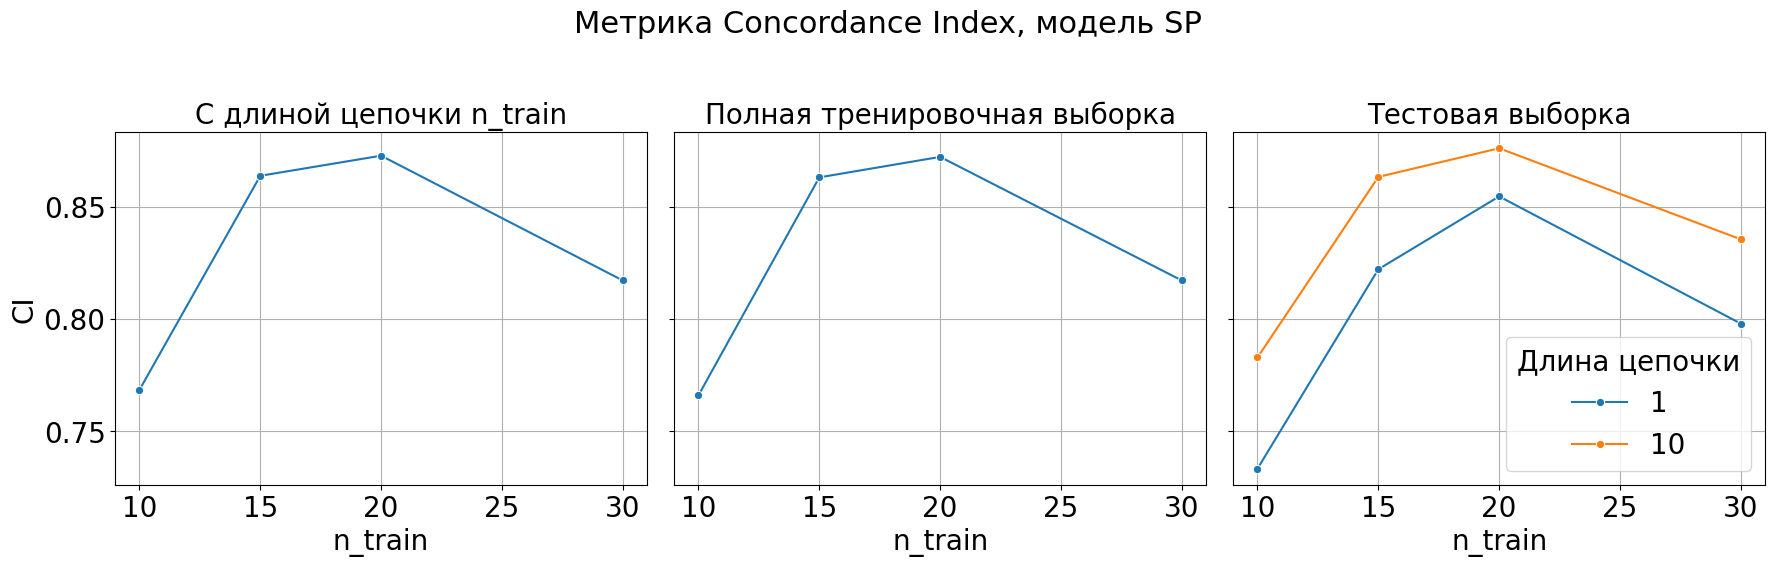

In [10]:
plt.rcParams["figure.figsize"] = (14,8)
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 15

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=30)    # fontsize of the tick labels
plt.rc('ytick', labelsize=30)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
draw_all_metrics_plots(df, 'ci', full_metrics_name='Concordance Index', method = 'SP')


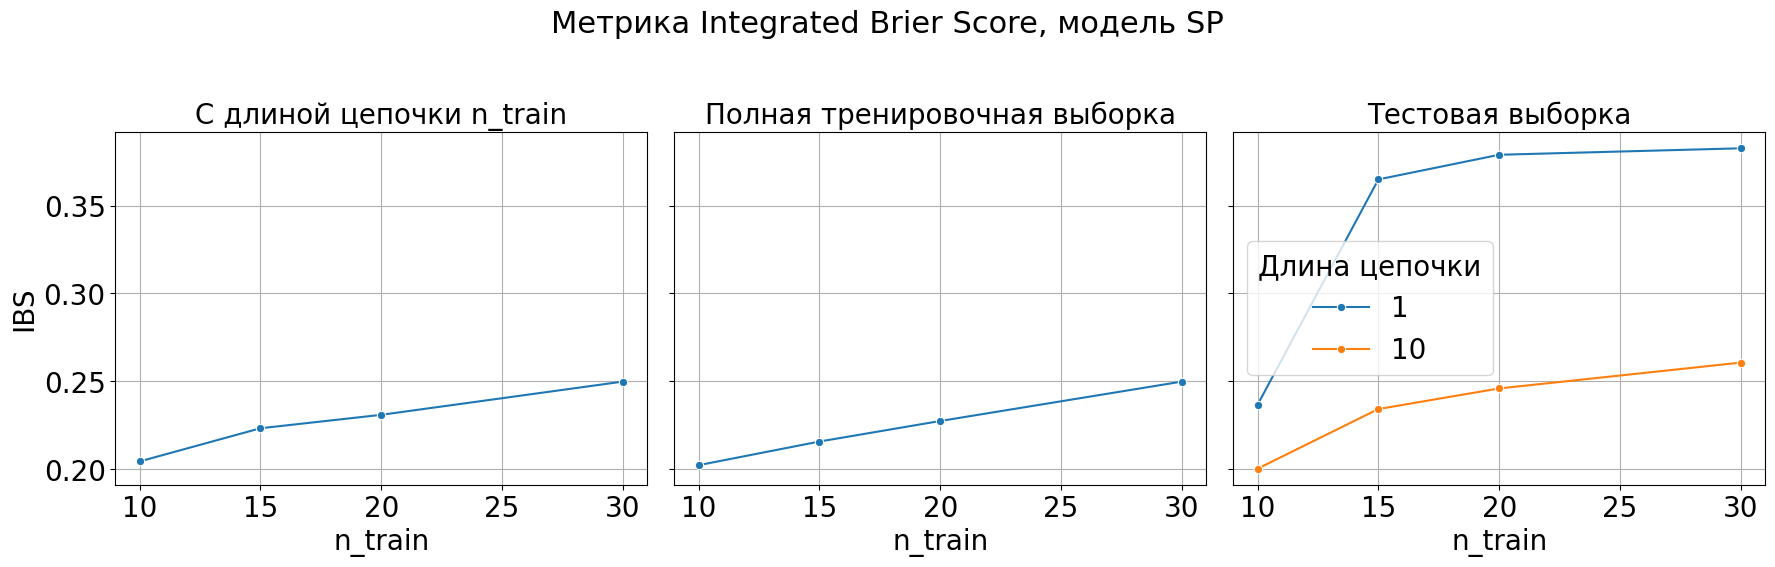

In [11]:
draw_all_metrics_plots(df, 'ibs', full_metrics_name='Integrated Brier Score', method='SP')

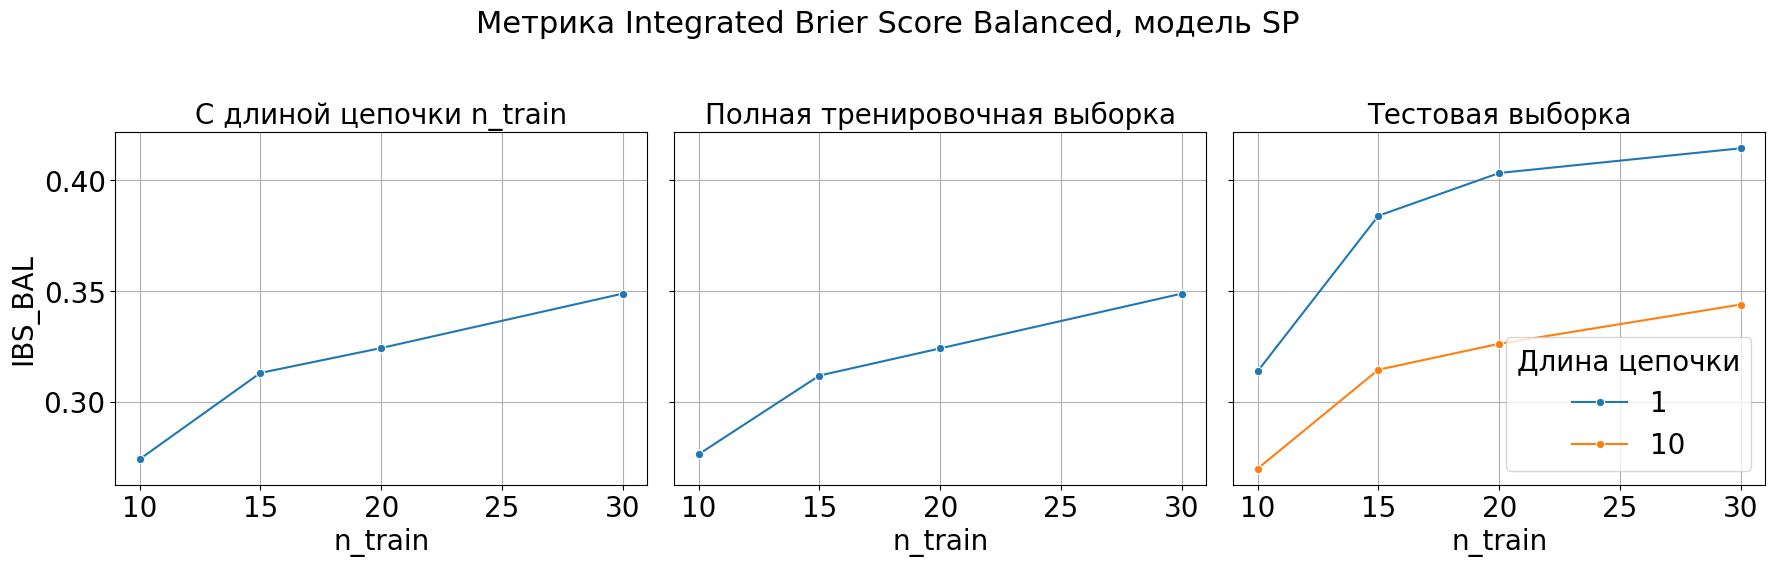

In [12]:
draw_all_metrics_plots(df, 'ibs_bal', full_metrics_name='Integrated Brier Score Balanced', method='SP')

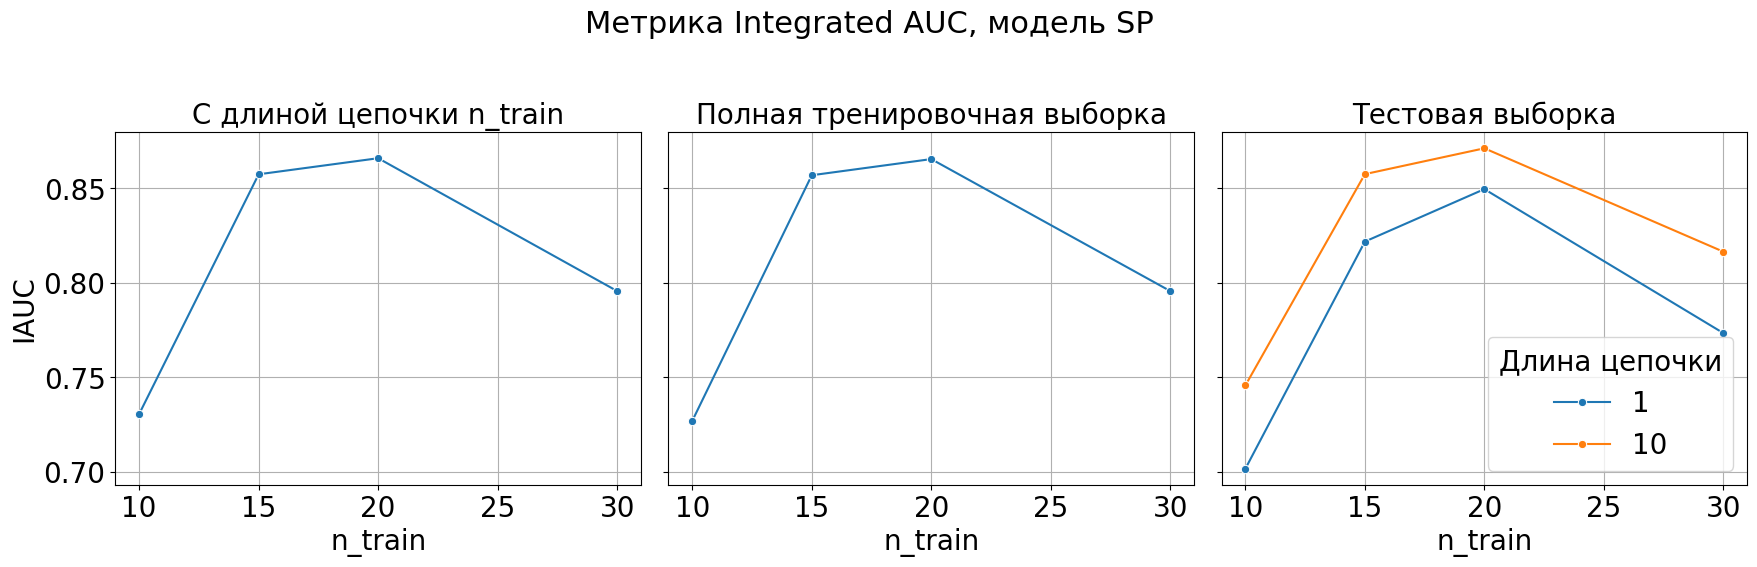

In [13]:
draw_all_metrics_plots(df, 'iauc', full_metrics_name='Integrated AUC', method='SP')


In [14]:
df[(df['test_samples'] == 1) & (df['train_samples'] == 20)]

,train_samples,test_samples,method,hidden_dim,train_time,test_time,error,error_text,model_id,ibs_bal_train_same_size,...,ci_train_max_size,ci_test,iauc_train_same_size,iauc_train_max_size,iauc_test,ibs_train_same_size,ibs_train_max_size,ibs_test,l1_ratio,penalizer
4,20,1,SP,2048,1506.088247,4.023057,0,NaN,3_SP,0.3243,...,0.872135,0.854515,0.865972,0.865513,0.849616,0.230859,0.227345,0.378966,NaN,NaN


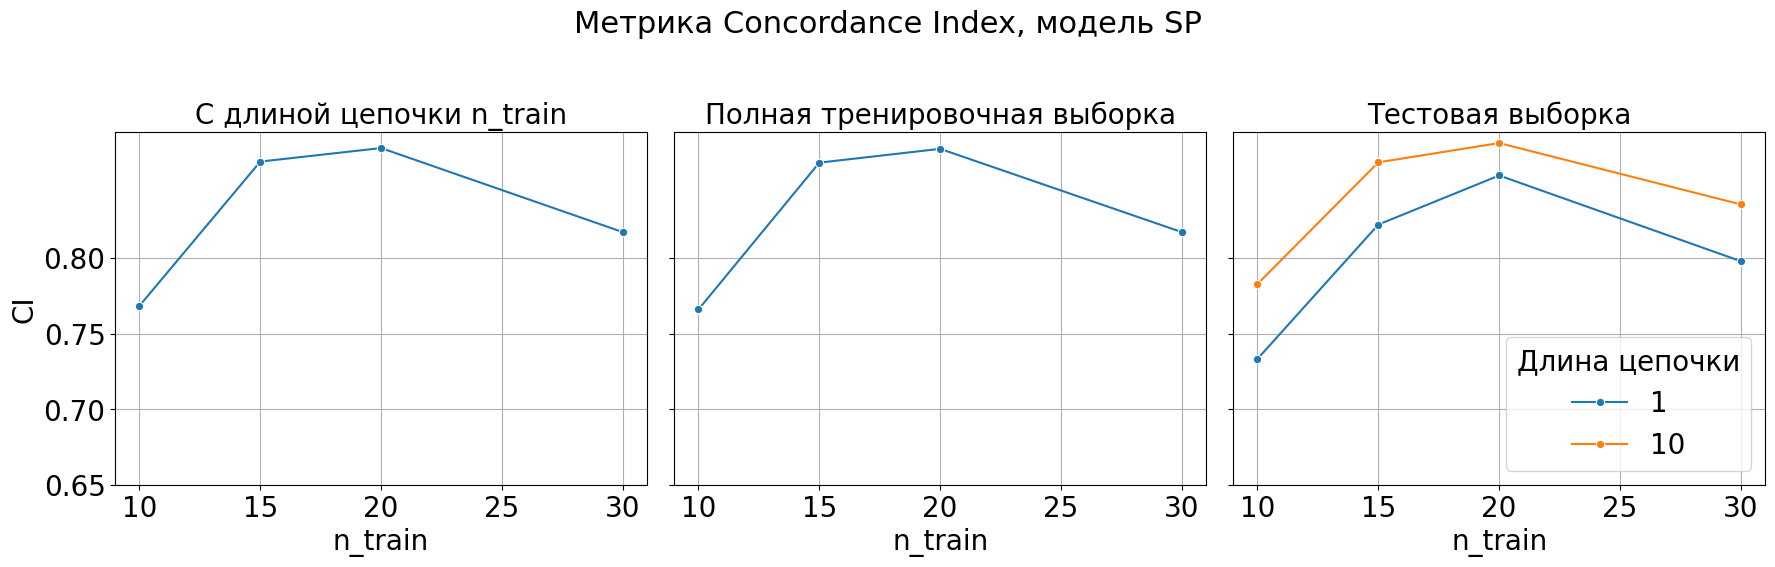

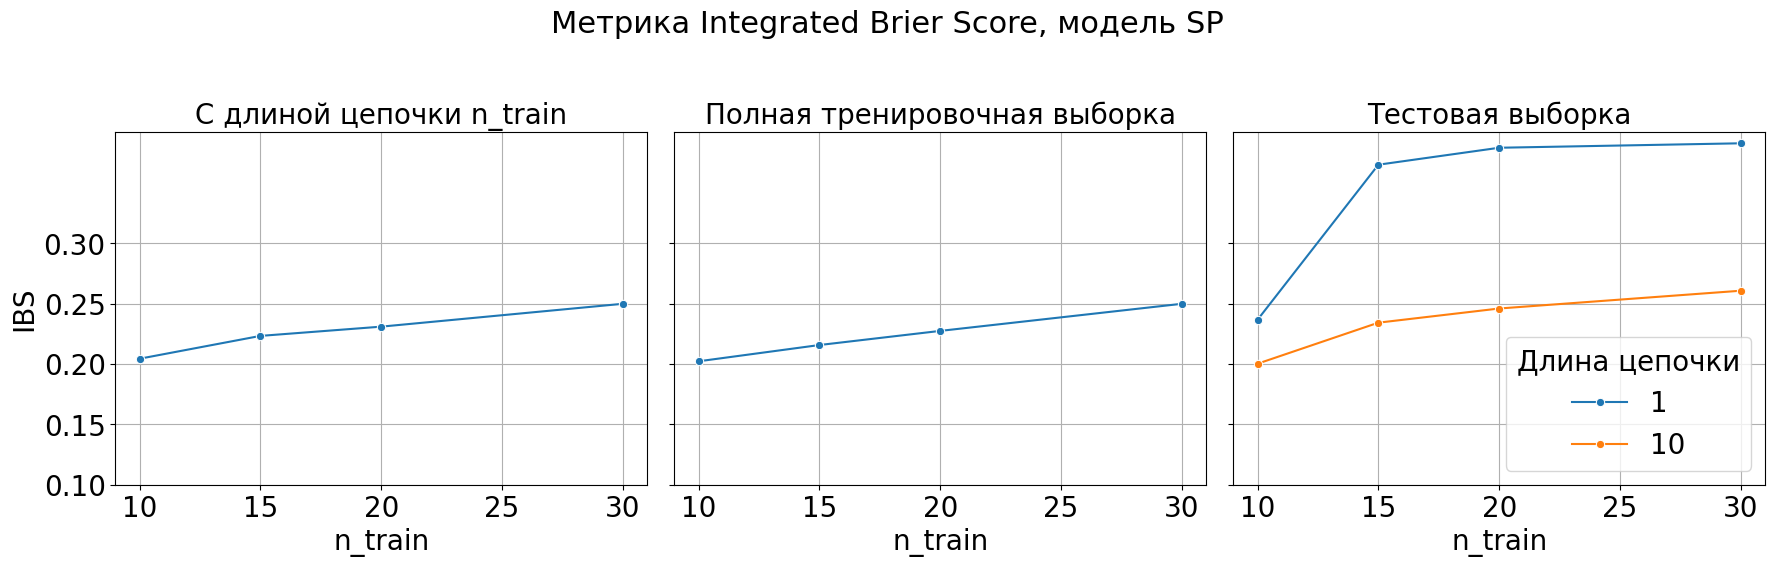

In [15]:
draw_all_metrics_plots(df, 'ci', np.arange(0.65, 0.85, 0.05), full_metrics_name='Concordance Index', method = 'SP')
draw_all_metrics_plots(df, 'ibs', np.arange(0.10, 0.35, 0.05), full_metrics_name='Integrated Brier Score', method='SP')


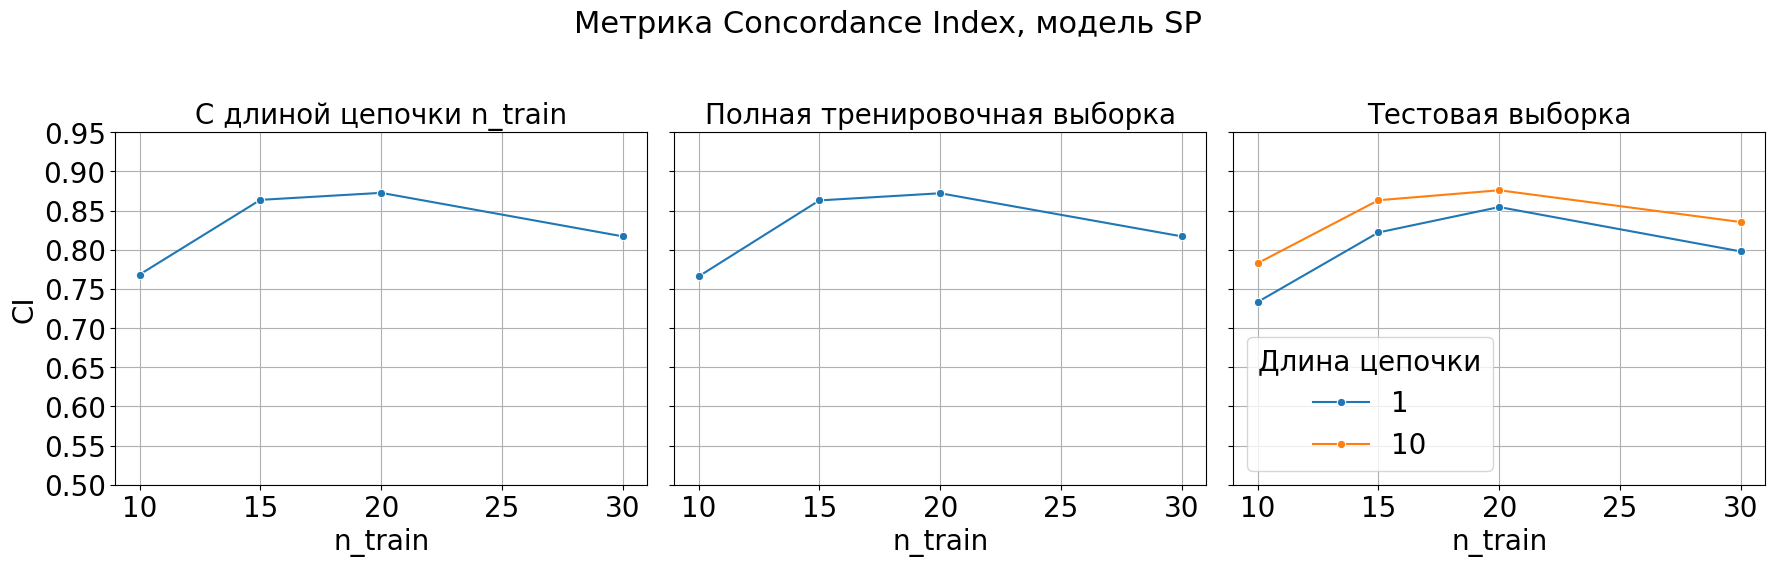

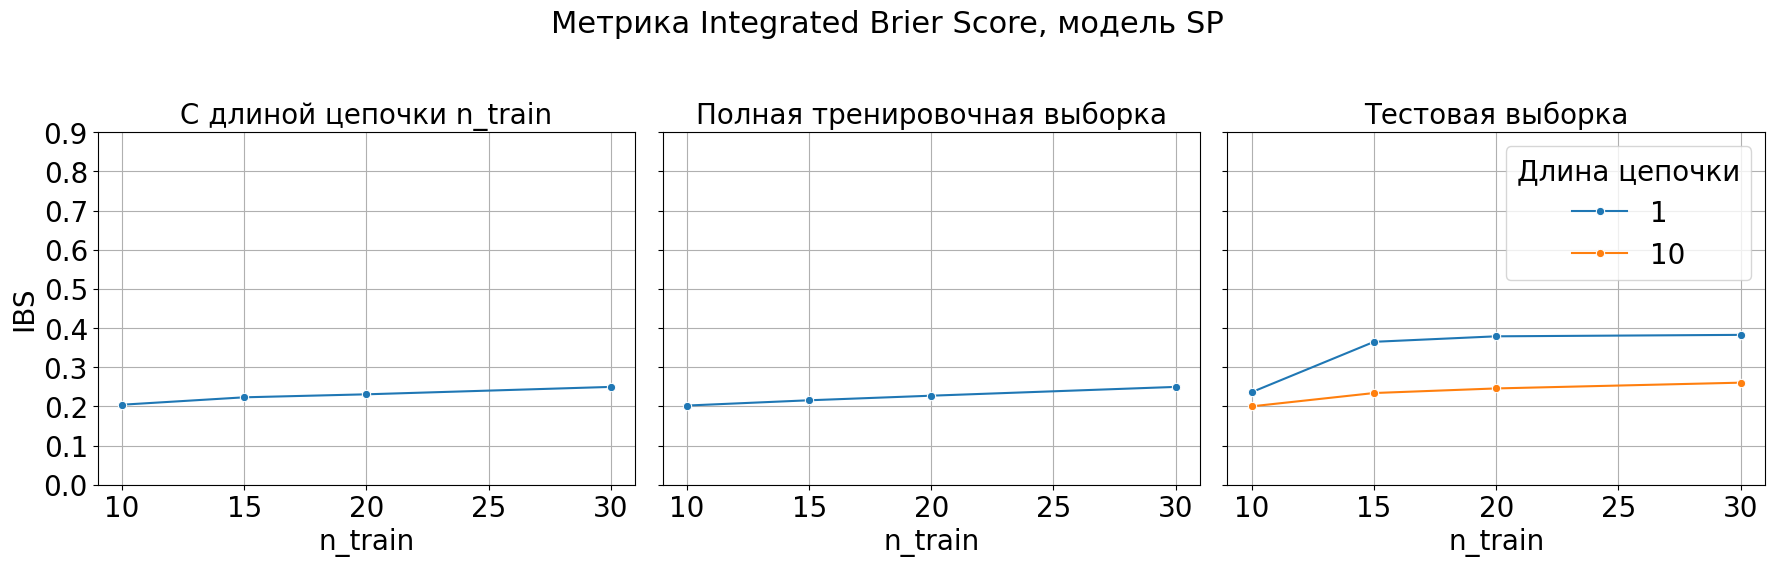

In [16]:
draw_all_metrics_plots(df, 'ci', np.arange(0.5, 1, 0.05), full_metrics_name='Concordance Index', method = 'SP')
draw_all_metrics_plots(df, 'ibs', np.arange(0, 1, 0.1), full_metrics_name='Integrated Brier Score', method='SP')


In [17]:
def draw_all_metrics_agg(df_full, metric, ticks, full_metrics_name=None, method = None):
    if not method is None:
        df = df_full[df_full['method'] == method]
    else:
        df = df_full
        
    test_grid = df['test_samples'].dropna().unique()
    test_grid_sz = len(test_grid)
    
    fig, ax = plt.subplots(1, 2 + test_grid_sz, sharey=True, tight_layout=True)
    fig.suptitle(f'Метрика {full_metrics_name if not full_metrics_name is None else metric}, модель {method}')

    metric_df = df.groupby('train_samples')[f'{metric}_train_same_size'].agg(['mean', 'min', 'max'])
    ax[0].plot(metric_df, marker='.')
    ax[0].set_yticks(ticks)
    ax[0].set_xlabel('n_train')
    ax[0].set_title(f'С длиной цепочки n_train')

    ax[0].grid()

    metric_df = df.groupby('train_samples')[f'{metric}_train_max_size'].agg(['mean', 'min', 'max'])
    ax[1].plot(metric_df, marker='.')
    ax[1].set_yticks(ticks)
    ax[1].set_title(f'C длиной цепочки максимального размера')
    ax[1].set_xlabel('n_train')
    ax[1].grid()
    
    for i, test_samples in enumerate(test_grid):
        metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[f'{metric}_test'].agg(['mean', 'min', 'max'])
        ax[i + 2].plot(metric_df, marker='.')
        ax[i + 2].set_xlabel('n_train')
        ax[i + 2].grid()
        
        ax[i + 2].set_yticks(ticks)
        ax[i + 2].set_title(f'Длина цепочки в тестовой выборке: {test_samples}')
    fig.savefig(f'fig_{metric}.jpg')

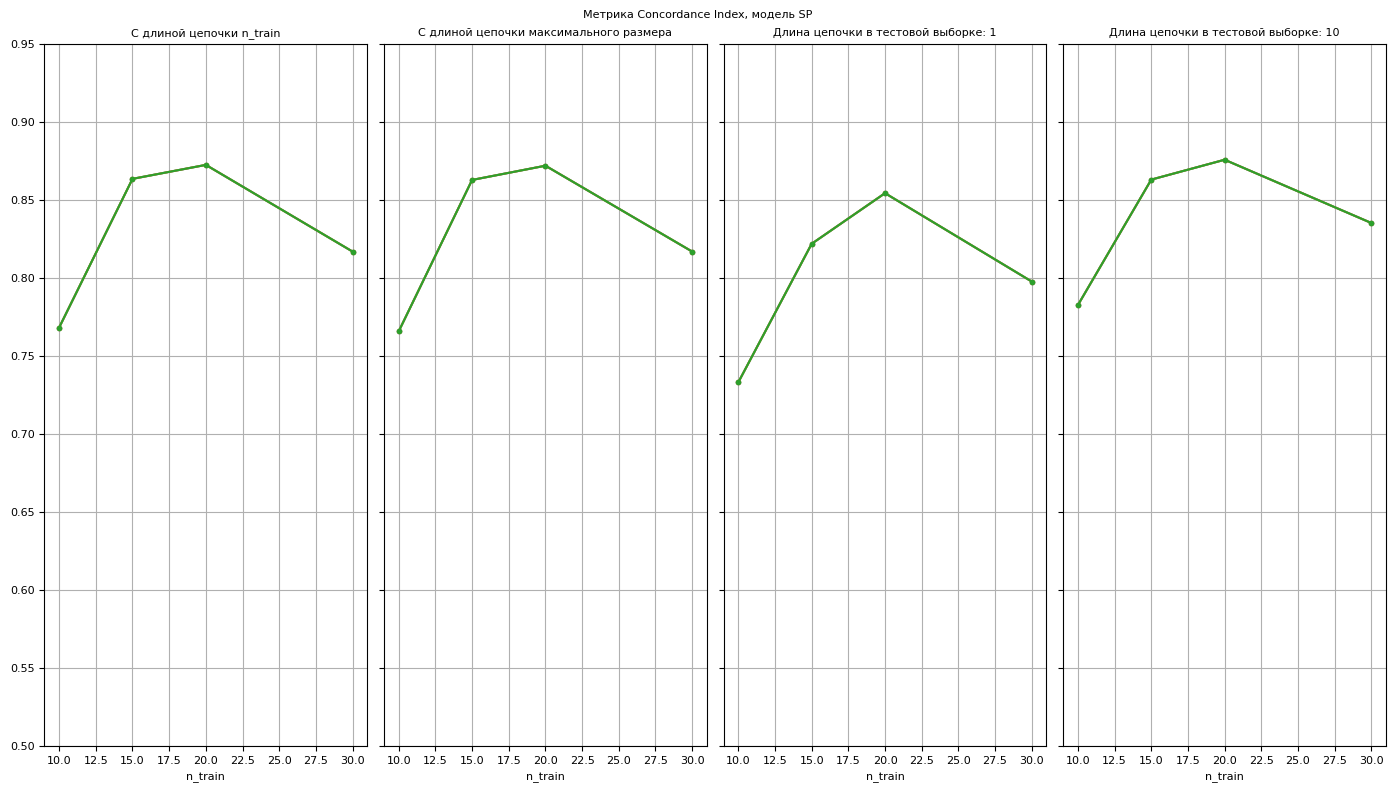

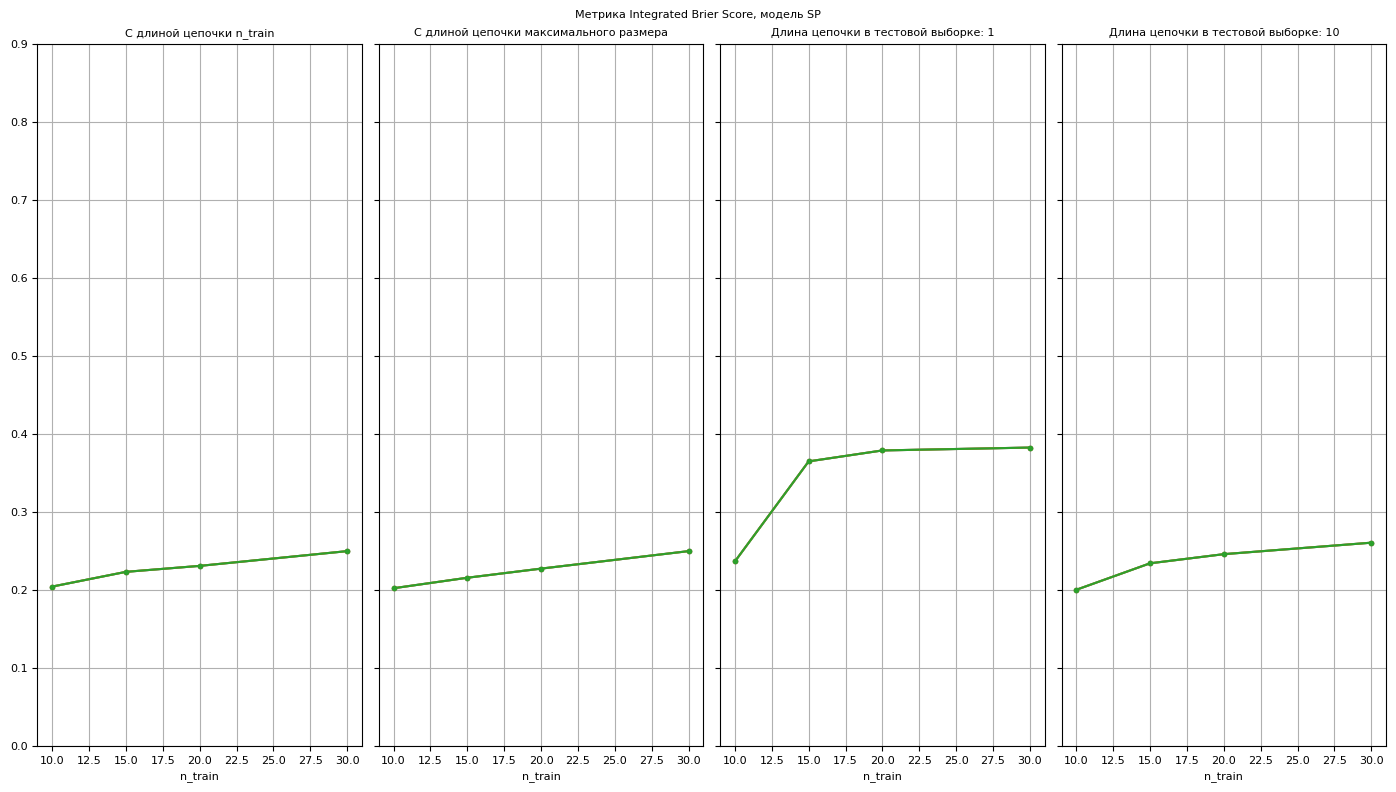

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.figsize"] = (14,8)
SMALL_SIZE = 6
MEDIUM_SIZE = 7
BIGGER_SIZE = 8

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
draw_all_metrics_agg(df, 'ci', np.arange(0.5, 1, 0.05), full_metrics_name='Concordance Index', method = 'SP')
draw_all_metrics_agg(df, 'ibs', np.arange(0, 1, 0.1), full_metrics_name='Integrated Brier Score', method='SP')


In [19]:
# from modules.constants import TEST_GRID

# for test_samples in TEST_GRID:
#     fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
#     fig.suptitle(f'test_samples={test_samples}')
#     draw_pandas_plot(df, 'ci_train_same_size', np.arange(0.0, 1.1, 0.05), test_samples=test_samples, ax = ax[0])
#     draw_pandas_plot(df, 'ci_train_max_size', np.arange(0.0, 1.1, 0.05), test_samples=test_samples,ax = ax[1])
#     draw_pandas_plot(df, 'ci_test', np.arange(0.0, 1.1, 0.05), test_samples=test_samples,ax=ax[2])
    
# for test_samples in TEST_GRID:
#     fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
#     fig.suptitle(f'test_samples={test_samples}')
#     draw_pandas_plot(df, 'ibs_train_same_size', np.arange(0.0, 1.1, 0.05), test_samples=test_samples, ax = ax[0])
#     draw_pandas_plot(df, 'ibs_train_max_size', np.arange(0.0, 1.1, 0.05), test_samples=test_samples,ax = ax[1])
#     draw_pandas_plot(df, 'ibs_test', np.arange(0.0, 1.1, 0.05), test_samples=test_samples,ax=ax[2])

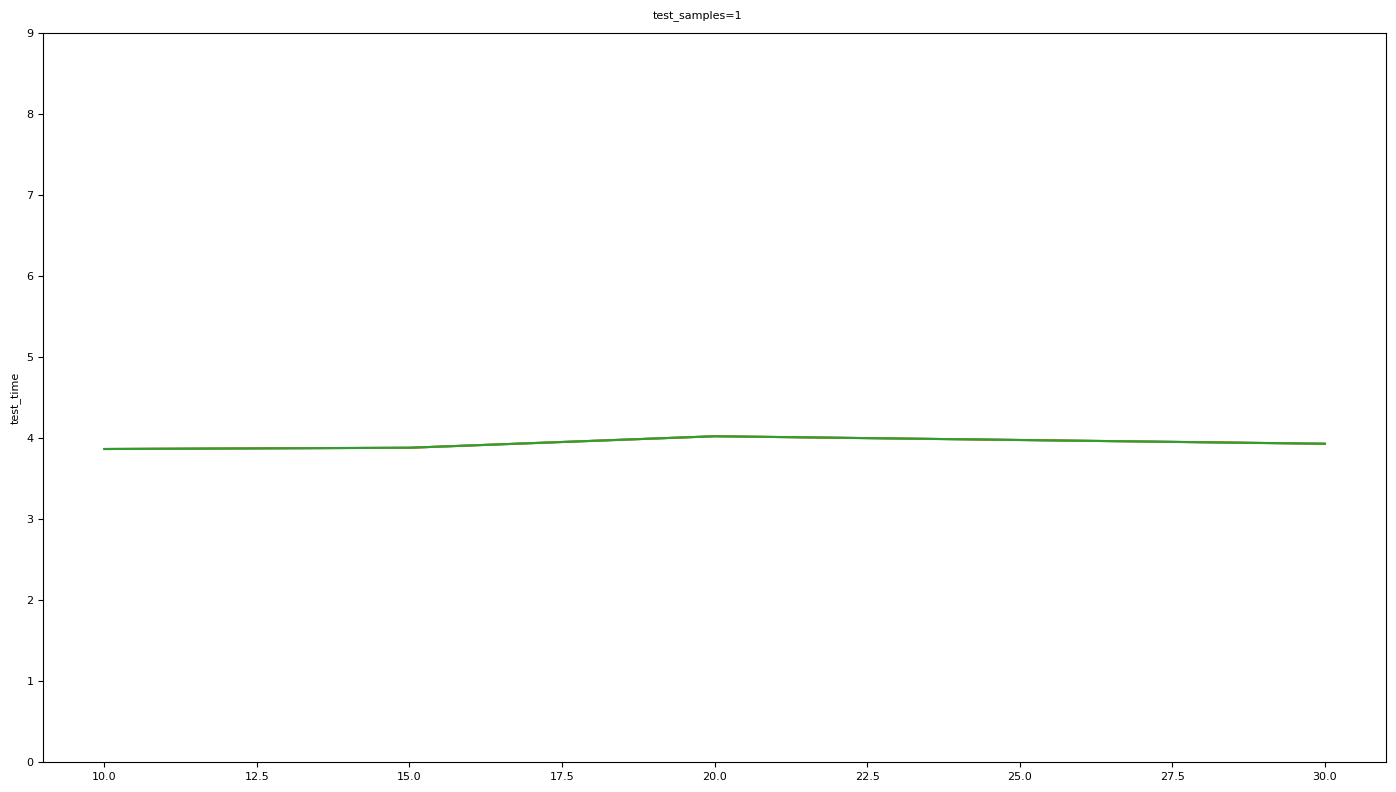

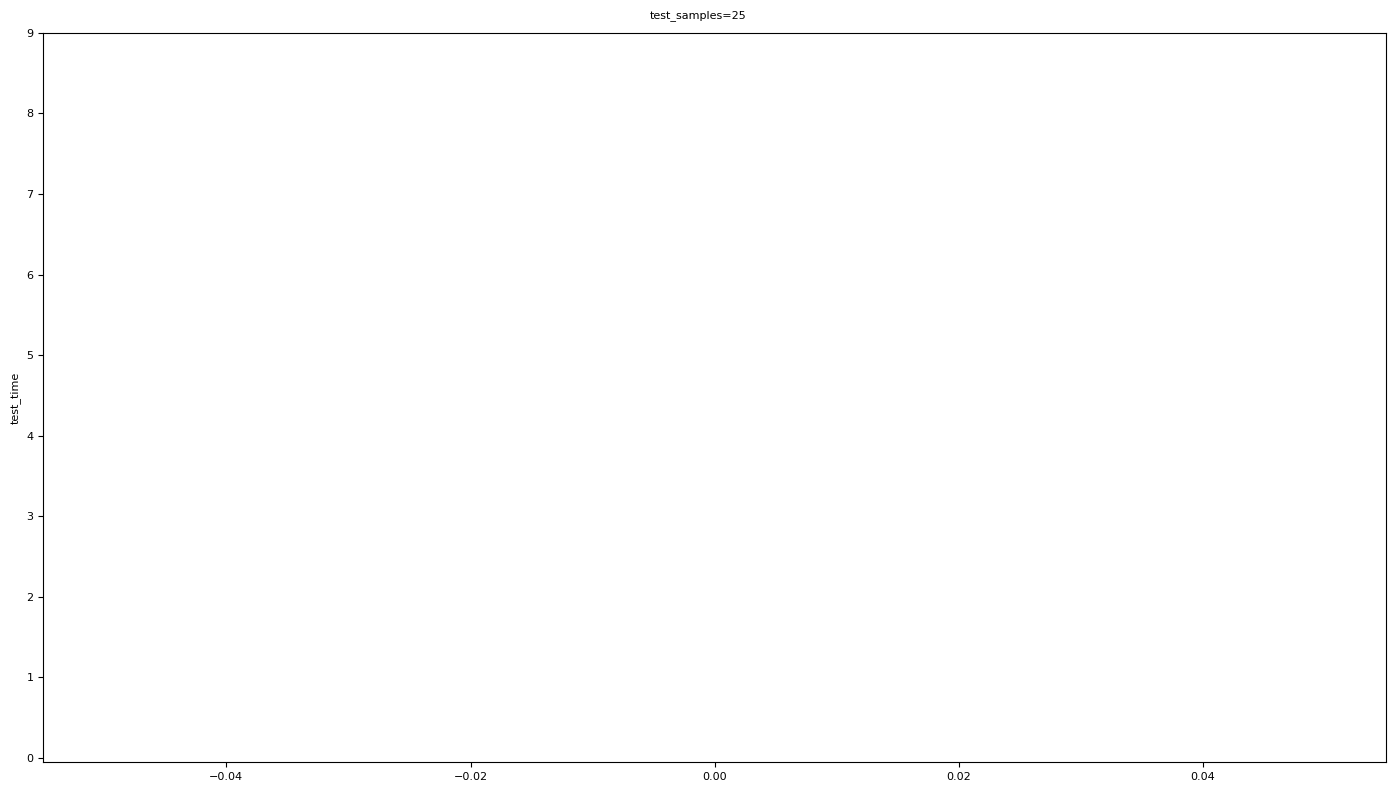

In [20]:
for test_samples in [1, 25]:
    fig, ax = plt.subplots(1, sharey=True, tight_layout=True)
    fig.suptitle(f'test_samples={test_samples}')
    draw_pandas_plot(df, 'test_time', np.arange(0, 10, 1), test_samples=test_samples, ax = ax)

Text(0, 0.5, 'Время обучения, с')

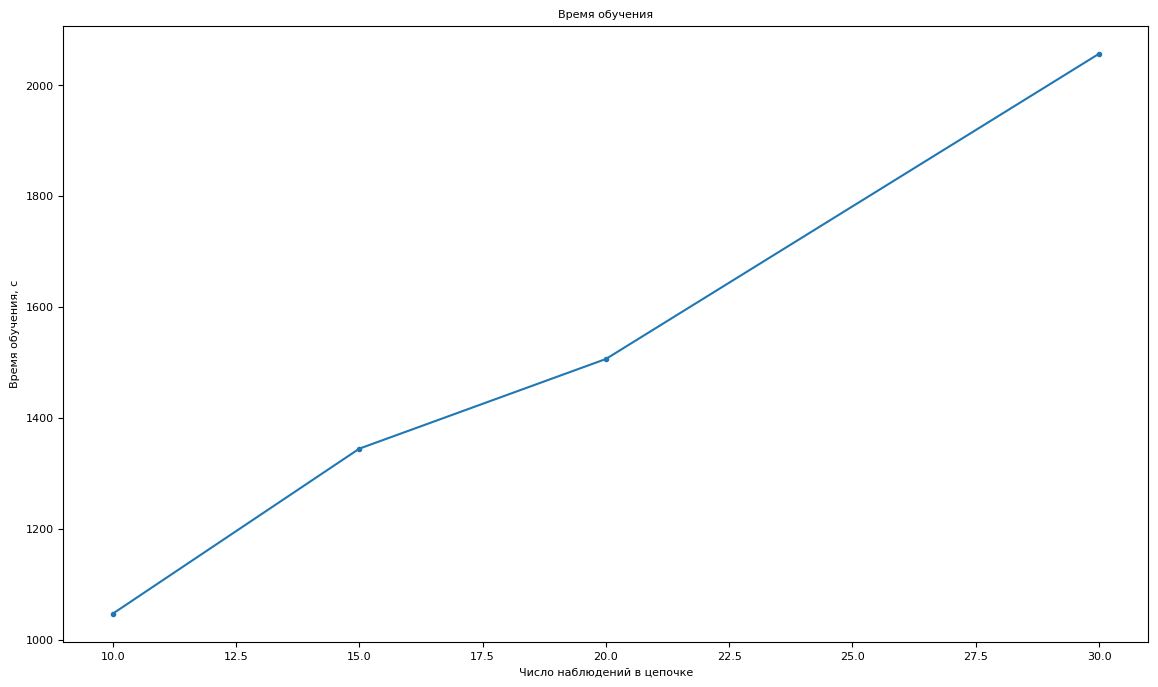

In [21]:
metric_df = df[df['test_samples'] == 1].groupby('train_samples')['train_time'].agg(['median'])
plt.plot(metric_df, marker='.')
plt.title('Время обучения')
plt.xlabel('Число наблюдений в цепочке')
plt.ylabel('Время обучения, с')

0

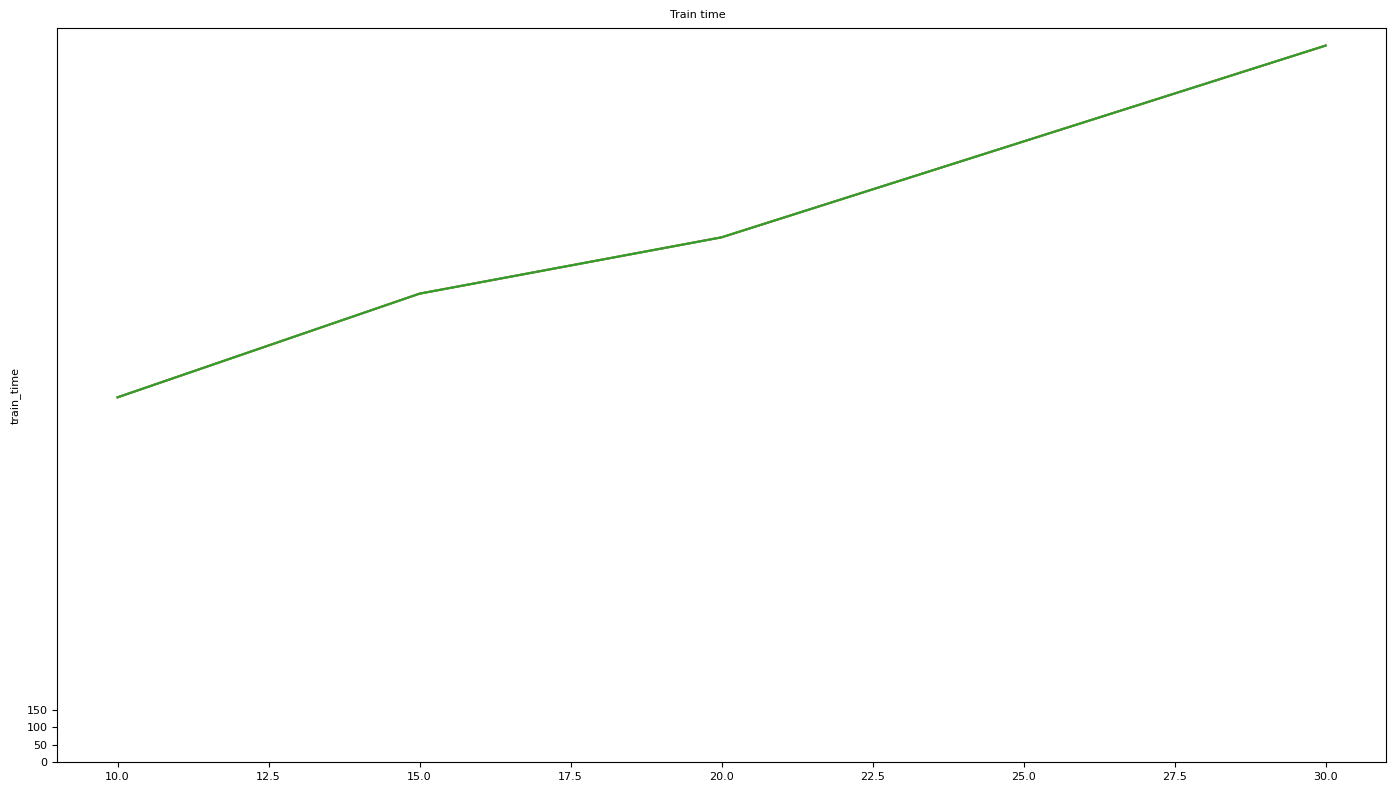

In [22]:

fig, ax = plt.subplots(1, sharey=True, tight_layout=True)
fig.suptitle(f'Train time')
draw_pandas_plot(df, 'train_time', np.arange(0, 200, 50), test_samples=1, ax = ax)

0

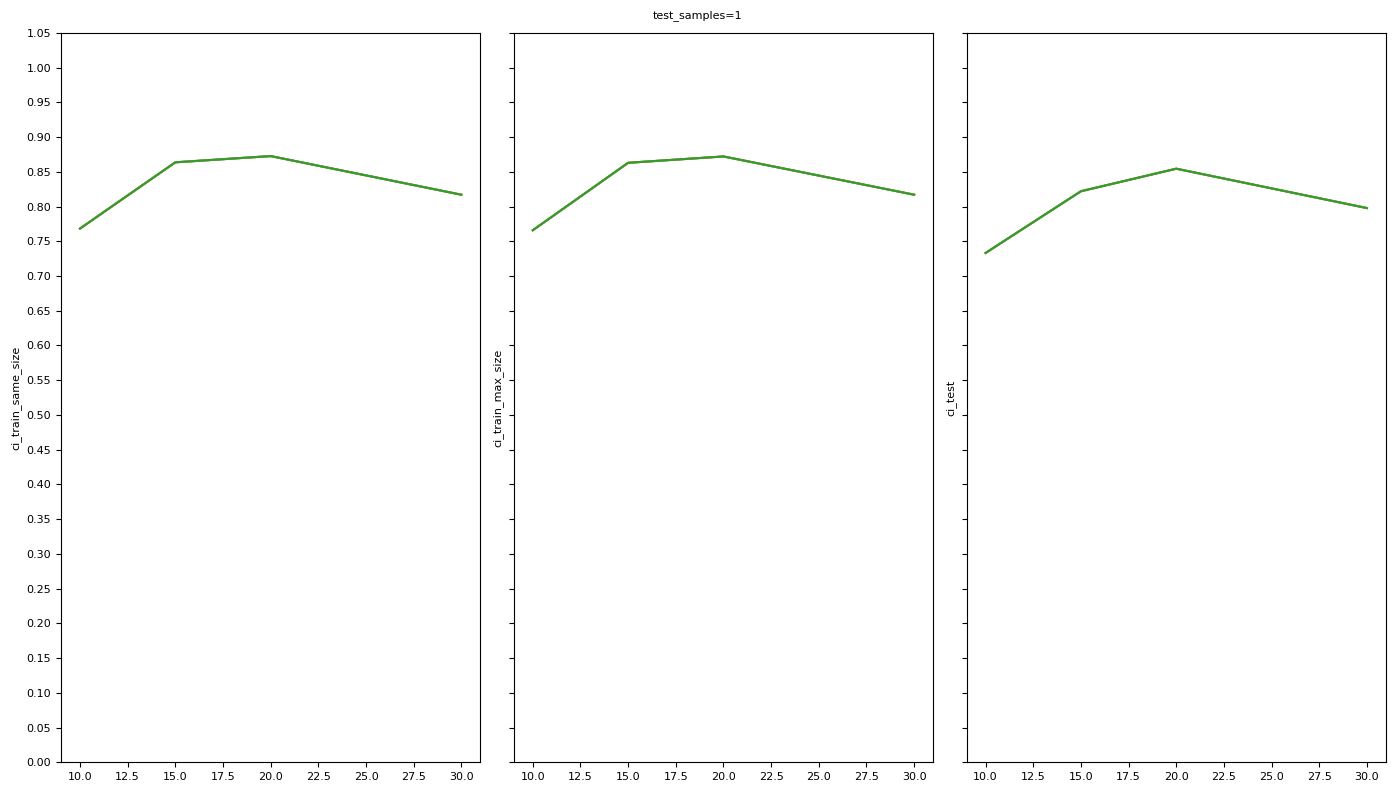

In [23]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
fig.suptitle('test_samples=1')
draw_pandas_plot(df, 'ci_train_same_size', np.arange(0.0, 1.1, 0.05), ax = ax[0])
draw_pandas_plot(df, 'ci_train_max_size', np.arange(0.0, 1.1, 0.05), ax = ax[1])
draw_pandas_plot(df, 'ci_test', np.arange(0.0, 1.1, 0.05), ax=ax[2])

0

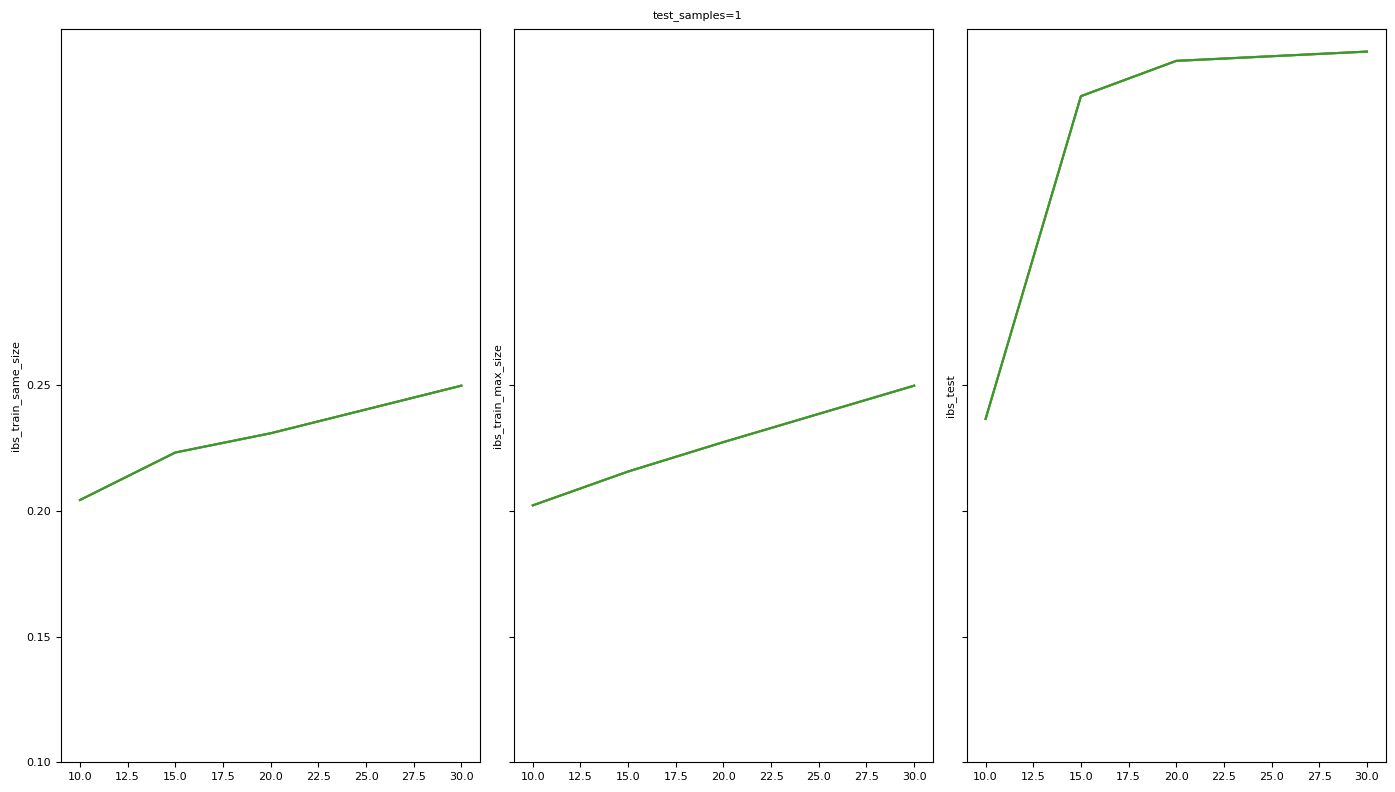

In [24]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
fig.suptitle('test_samples=1')
draw_pandas_plot(df, 'ibs_train_same_size', np.arange(0.1, 0.3, 0.05), ax=ax[0])
draw_pandas_plot(df, 'ibs_train_max_size', np.arange(0.1, 0.3, 0.05), ax=ax[1])
draw_pandas_plot(df, 'ibs_test', np.arange(0.1, 0.3, 0.05), ax=ax[2])


In [25]:
df_top = df.sort_values(by='ibs_train_same_size', ascending=True).groupby('train_samples').head(7)

In [26]:
def draw_mean_plot(df, metric, ticks, test_samples=1, ax=None):
    metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[metric].agg(['mean'])
    if not ax is None:
        ax.plot(metric_df)
        ax.set_yticks(ticks)
        ax.set_ylabel(metric)
        return 0
    return plt.plot(metric_df)

0

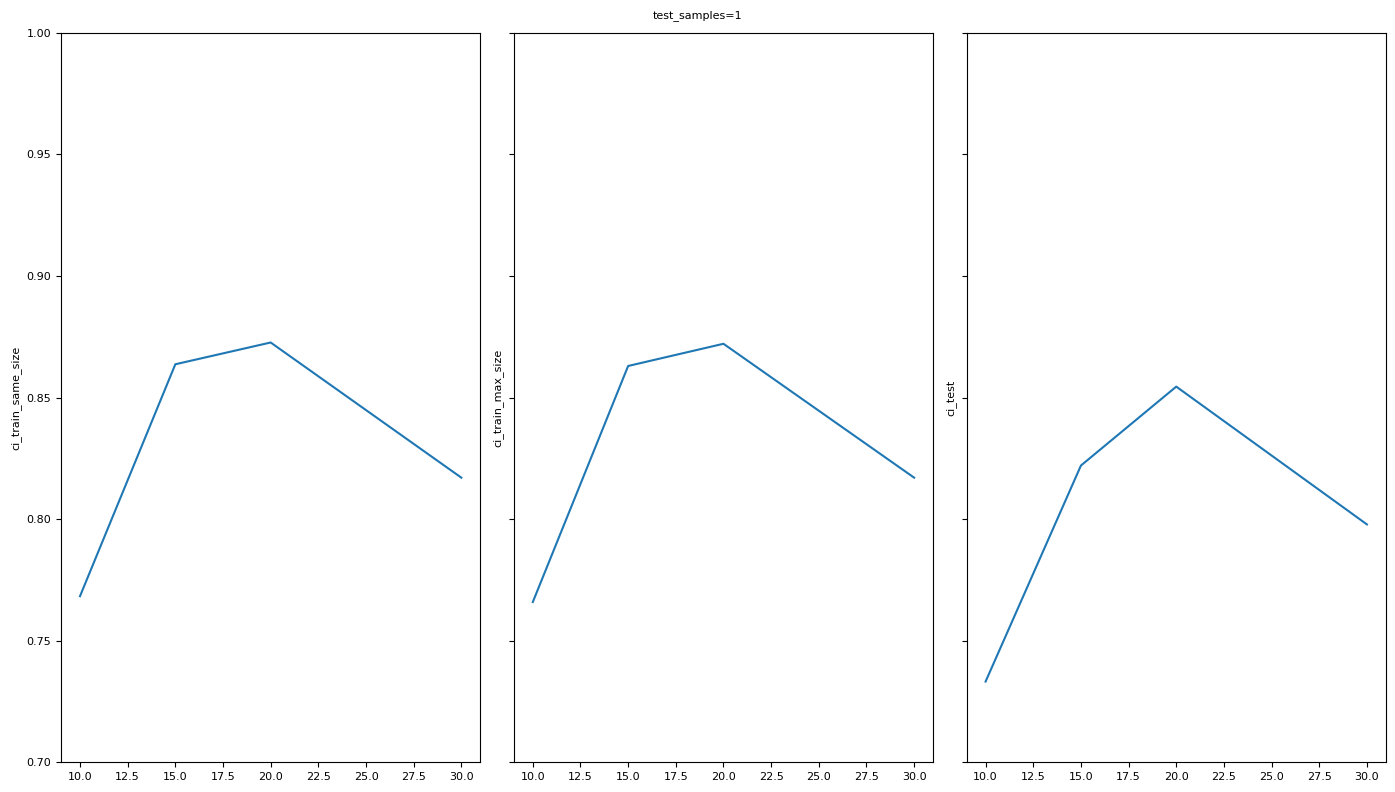

In [27]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
fig.suptitle('test_samples=1')
draw_mean_plot(df_top, 'ci_train_same_size', np.arange(0.7, 1, 0.05), ax=ax[0])
draw_mean_plot(df_top, 'ci_train_max_size', np.arange(0.7, 1, 0.05), ax=ax[1])
draw_mean_plot(df_top, 'ci_test', np.arange(0.7, 1, 0.05), ax=ax[2])

0

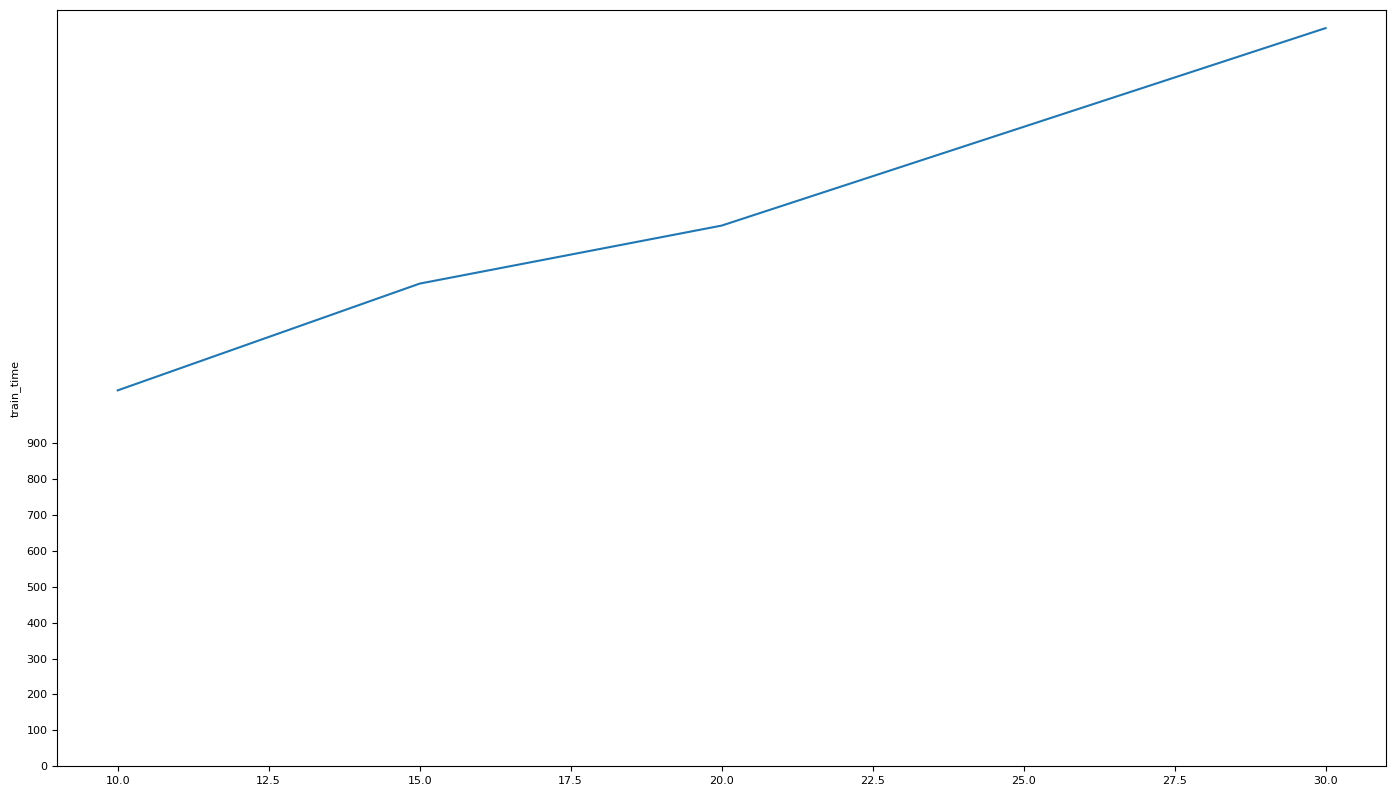

In [28]:
fig, ax = plt.subplots(1, sharey=True, tight_layout=True)
draw_mean_plot(df_top, 'train_time', np.arange(0, 1000, 100), ax=ax)

0

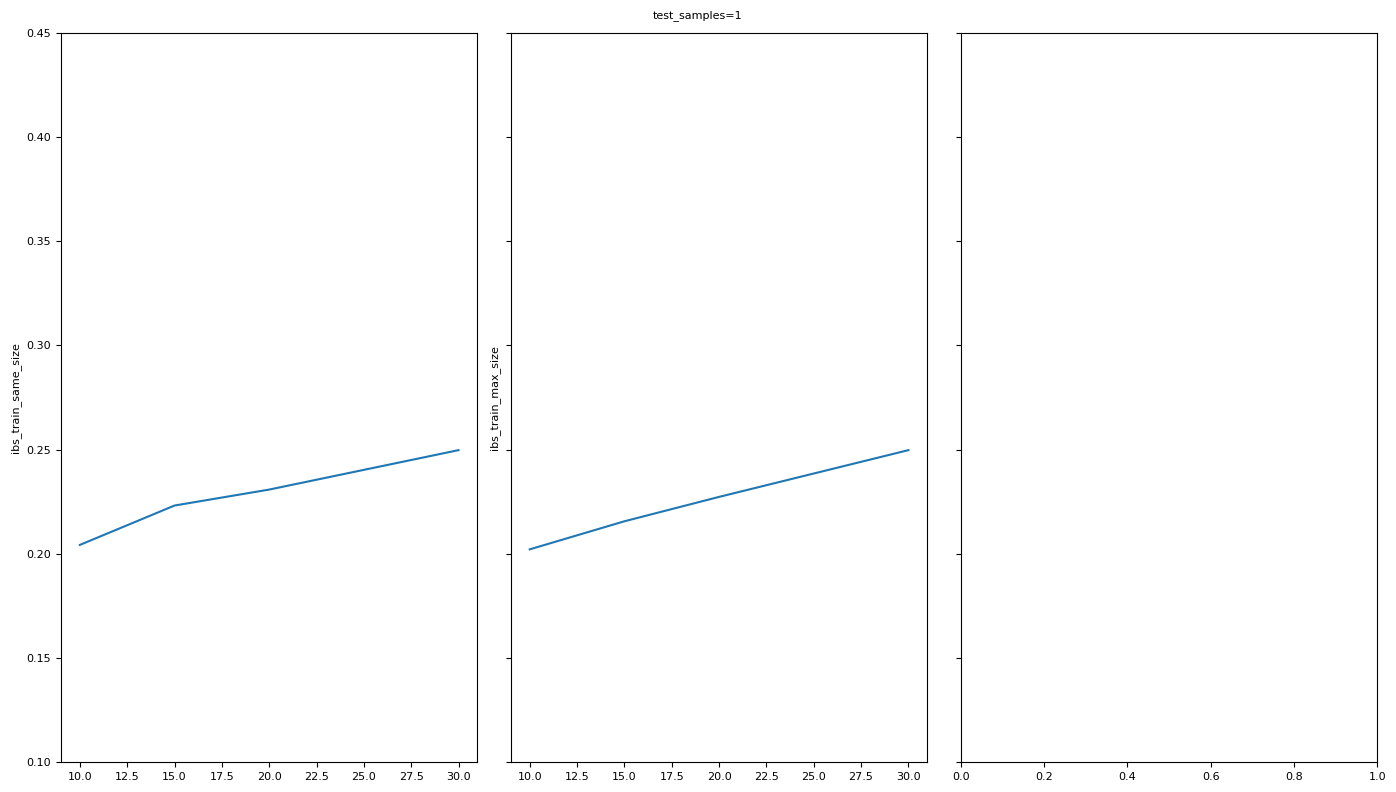

In [29]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
fig.suptitle('test_samples=1')
draw_mean_plot(df_top, 'ibs_train_same_size', np.arange(0.1, 0.50, 0.05), ax=ax[0])
draw_mean_plot(df_top, 'ibs_train_max_size', np.arange(0.1, 0.50, 0.05), ax=ax[1])
# draw_mean_plot(df_top, 'ibs_test', np.arange(0.1, 0.50, 0.05), ax=ax[2])a

0

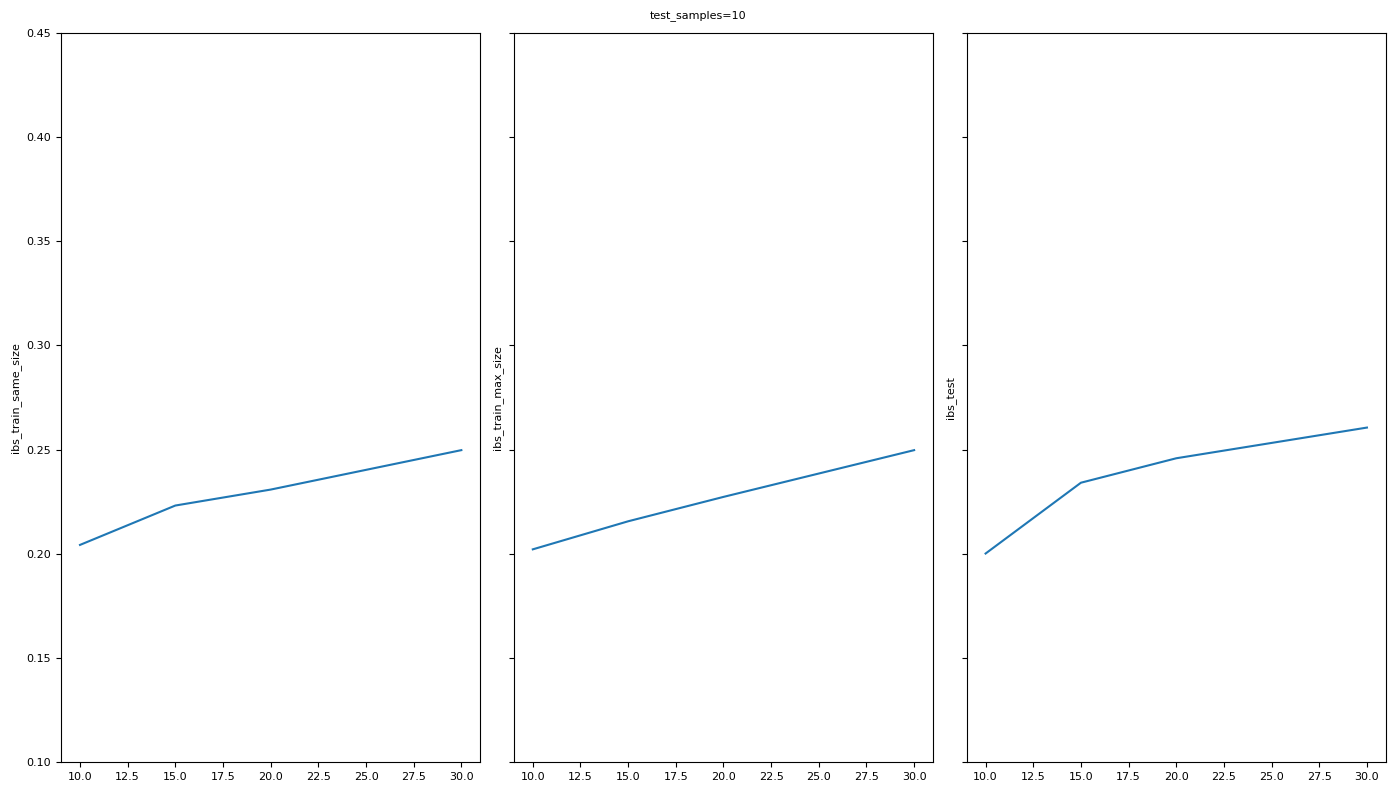

In [30]:
fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True)
fig.suptitle('test_samples=10')
draw_mean_plot(df_top, 'ibs_train_same_size', np.arange(0.1, 0.50, 0.05),test_samples=10, ax=ax[0])
draw_mean_plot(df_top, 'ibs_train_max_size', np.arange(0.1, 0.50, 0.05), test_samples=10,ax=ax[1])
draw_mean_plot(df_top, 'ibs_test', np.arange(0.1, 0.50, 0.05), test_samples=10,ax=ax[2])

KeyError: 'Column not found: ci_train'

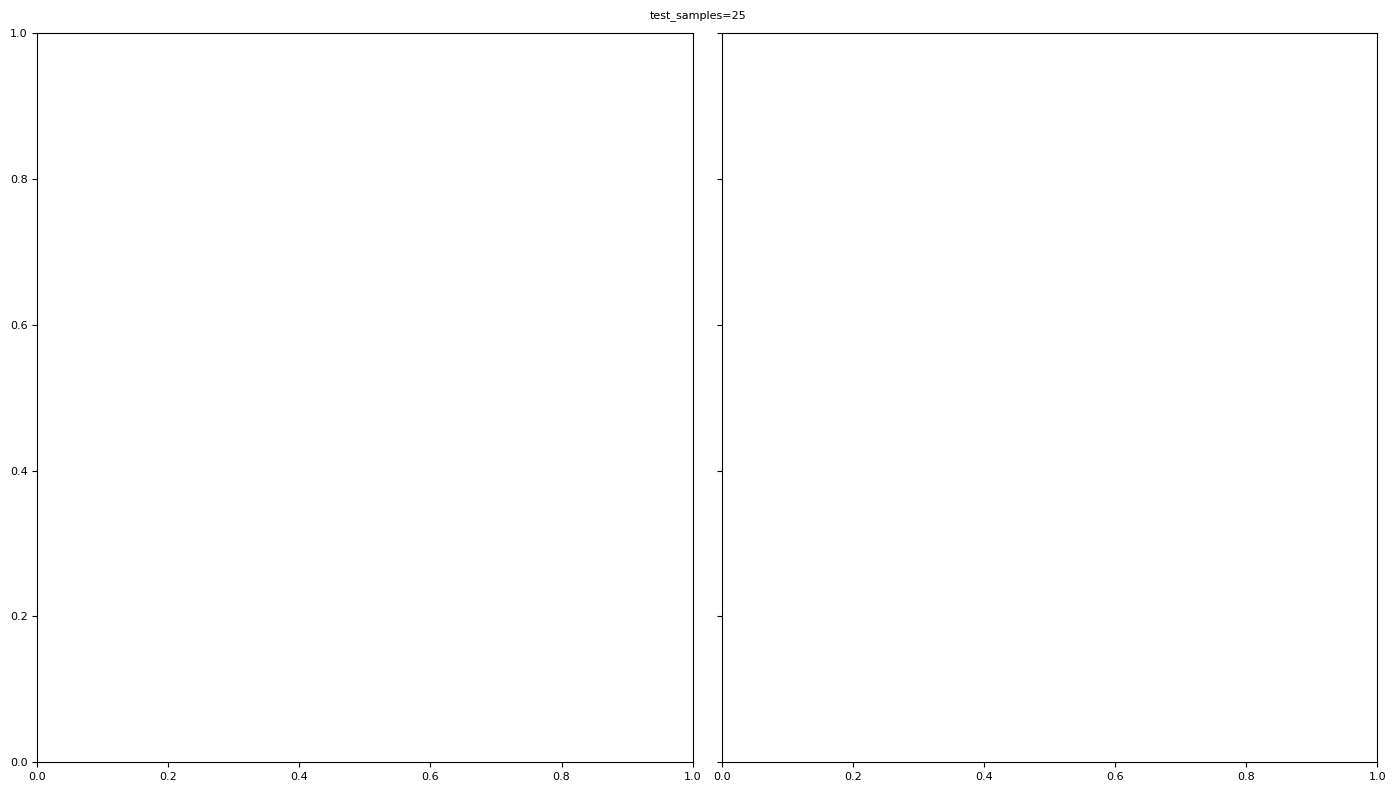

In [31]:
fig, ax = plt.subplots(1, 2, sharey=True, tight_layout=True)
fig.suptitle('test_samples=25')
draw_pandas_plot(df, 'ci_train', np.arange(0.4, 1.1, 0.05), test_samples=25, ax = ax[0])
draw_pandas_plot(df, 'ci_test', np.arange(0.4, 1.1, 0.05), test_samples=25, ax=ax[1])

KeyError: 'Column not found: ibs_train'

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

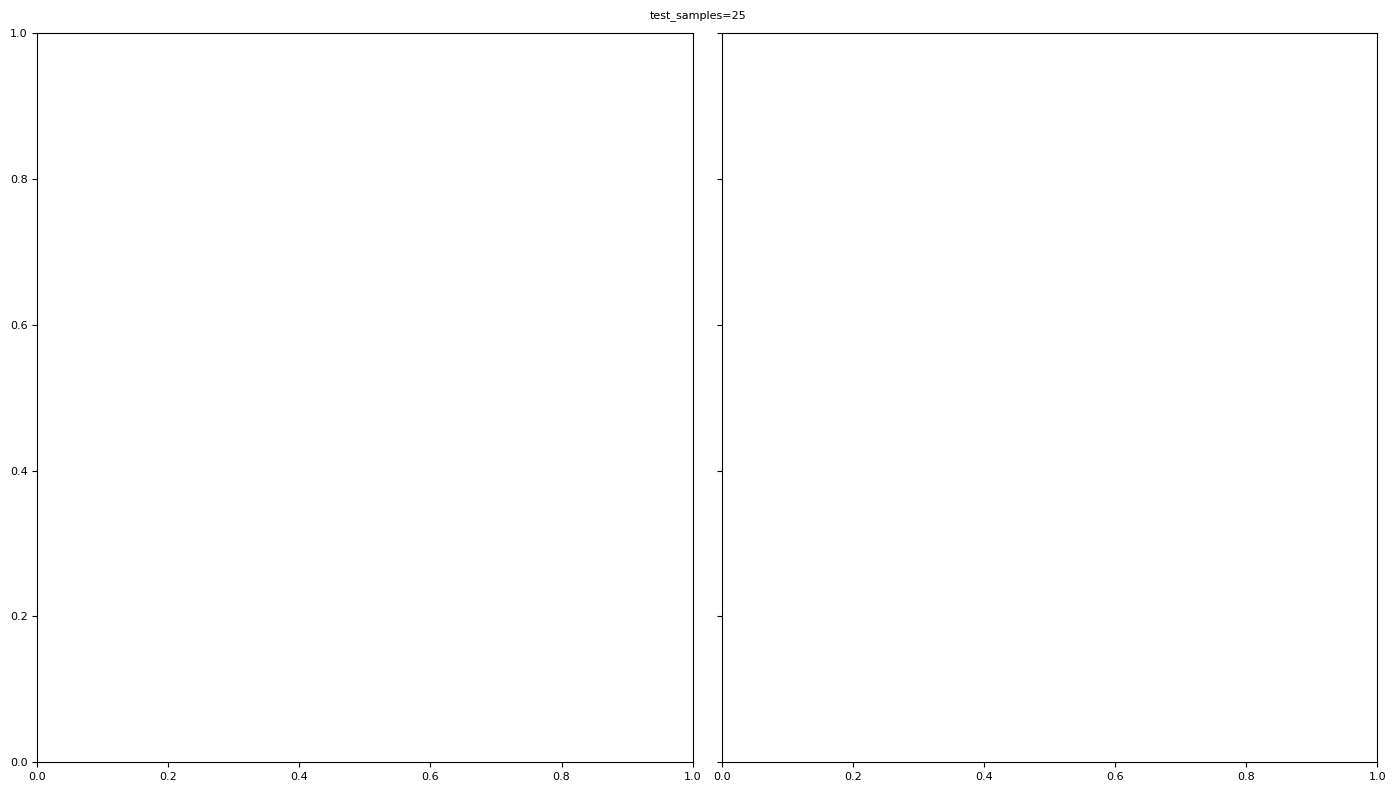

In [ ]:
fig, ax = plt.subplots(1, 2, sharey=True, tight_layout=True)
fig.suptitle('test_samples=25')
draw_pandas_plot(df, 'ibs_train', np.arange(0.1, 1.1, 0.05), test_samples=25, ax = ax[0])
draw_pandas_plot(df, 'ibs_test', np.arange(0.1, 1.1, 0.05), test_samples=25, ax=ax[1])

In [ ]:
# import matplotlib.pyplot as plt
# def draw_all_metrics_plots(df, metric, ticks, full_metrics_name=None):
#     test_grid = df['test_samples'].dropna().unique()
#     test_grid_sz = len(test_grid)
    
#     fig, ax = plt.subplots(1, 2, sharey=True, tight_layout=True)
#     fig.suptitle(f'Метрика {full_metrics_name if not full_metrics_name is None else metric}')

#     metric_df = df.groupby('train_samples')[f'{metric}_train_same_size'].agg(['mean', 'min', 'max'])
#     metric_df = df.groupby('train_samples')[f'{metric}_train_same_size'].agg(['mean'])
#     ax[0].plot(metric_df, marker='.')
#     ax[0].set_yticks(ticks)
#     ax[0].set_xlabel('n_train')
#     # ax[0].set_title(f'С длиной цепочки n_train')

#     ax[0].grid()

#     metric_df = df.groupby('train_samples')[f'{metric}_train_max_size'].agg(['mean', 'min', 'max'])
#     metric_df = df.groupby('train_samples')[f'{metric}_train_max_size'].agg(['mean'])
#     ax[0].plot(metric_df, marker='.')
#     ax[0].set_yticks(ticks)
#     ax[0].set_title(f'C длиной цепочки максимального размера')
#     ax[0].set_xlabel('n_train')
#     ax[0].grid()
    
#     for i, test_samples in enumerate(test_grid):
#         metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[f'{metric}_test'].agg(['mean', 'min', 'max'])
#         metric_df = df[df['test_samples'] == test_samples].groupby('train_samples')[f'{metric}_test'].agg(['mean'])
#         ax[1].plot(metric_df, marker='.')
#         ax[1].set_xlabel('n_train')
#         ax[1].grid()
        
#         ax[1].set_yticks(ticks)
#     ax[1].set_title(f'Длина цепочки в тестовой выборке: {test_samples}')
#     ax[1].legend([1, 10, 25], title='Длина цепочки')
#     fig.savefig(f'fig_{metric}.jpg')

: 

: 

# Агрегация

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('Agg_30_30_9.csv', index_col=False)

FileNotFoundError: [Errno 2] No such file or directory: 'Agg_30_30_9.csv'

In [ ]:
df

,train_samples,agg_samples,method,agg_method,agg_weight,ci_train,ibs_train,model_id
0,30,1,Cox,n_dist,0.1,0.791950,0.215078,152
1,30,1,Cox,n_dist,0.9,0.791950,0.215078,152
2,30,1,Cox,t_dist,1.0,0.791950,0.215078,152
3,30,1,Cox,t_dist,100.0,0.791950,0.215078,152
4,30,1,Cox,prob_dist,0.0,0.791950,0.215078,152
...,...,...,...,...,...,...,...,...
751,30,9,Cox,t_dist,1.0,0.743116,0.268317,165
752,30,9,Cox,t_dist,100.0,0.172779,0.230769,165
753,30,9,Cox,prob_dist,0.0,0.160920,0.219713,165
754,30,9,Cox,geom,0.1,0.155199,0.207362,165


In [ ]:
# import pickle 
# from torch.utils.data import DataLoader
# from disk_analyzer.models.Dataset import DiskDataset
# from disk_analyzer.stages.model_scoring import ModelScorer
# from Agg import TIMES

# with open('models/11_LogReg_model.pkl', 'rb') as f:
#     model = pickle.load(f)

# dl_train = DataLoader(
#     dataset=DiskDataset(mode='score', file_paths=['Preprocessed/30_train_preprocessed.csv']),
#     batch_size= 100000,
# )
# X_pred, X_gt = model.predict(dl_train, times = TIMES)
# scorer = ModelScorer()
# ci, ibs = scorer.get_ci_and_ibs(model, X_pred, X_gt, times=TIMES)
# print(ci, ibs)

  0%|          | 0/6 [00:00<?, ?it/s]

: 

: 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def draw_new_plot(df, method=None):
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    plot_df = df.copy()
    
    if method is not None:
        plot_df = plot_df[plot_df['method'] == method]

    plot_df['agg_label'] = plot_df['agg_method'].astype(str) + ' / w=' + plot_df['agg_weight'].astype(str)
    
    y_formatter = ScalarFormatter(useOffset=False)
    y_formatter.set_scientific(False)
    
    metrics = ['ci_train', 'ibs_train']
    
    for i, metric in enumerate(metrics):
        sns.lineplot(
            data=plot_df,
            x='agg_samples',
            y=metric,
            hue='agg_label',
            estimator='min',
            errorbar=None,
            markers=True,
            markersize=8,
            linewidth=2.5,
            ax=ax[i]
        )
        
        ax[i].yaxis.set_major_formatter(y_formatter)
        ax[i].ticklabel_format(axis='y', style='plain', useOffset=False)
        ax[i].get_yaxis().set_major_formatter(
            plt.FuncFormatter(lambda x, loc: f"{x:.6f}")
        )
        
        ax[i].set_title(
            f"{method if method else ''} - {metric}",
            fontsize=14
        )
        ax[i].set_xlabel("Number of Samples", fontsize=12)
        ax[i].set_ylabel(metric.upper(), fontsize=12)
        ax[i].tick_params(labelsize=10)
        ax[i].set_xticks(sorted(plot_df['agg_samples'].unique()))
        
        legend = ax[i].legend(title='Agg Method / Weight', title_fontsize=10, fontsize=12)
    
    plt.tight_layout()
    sns.despine()
    plt.show()


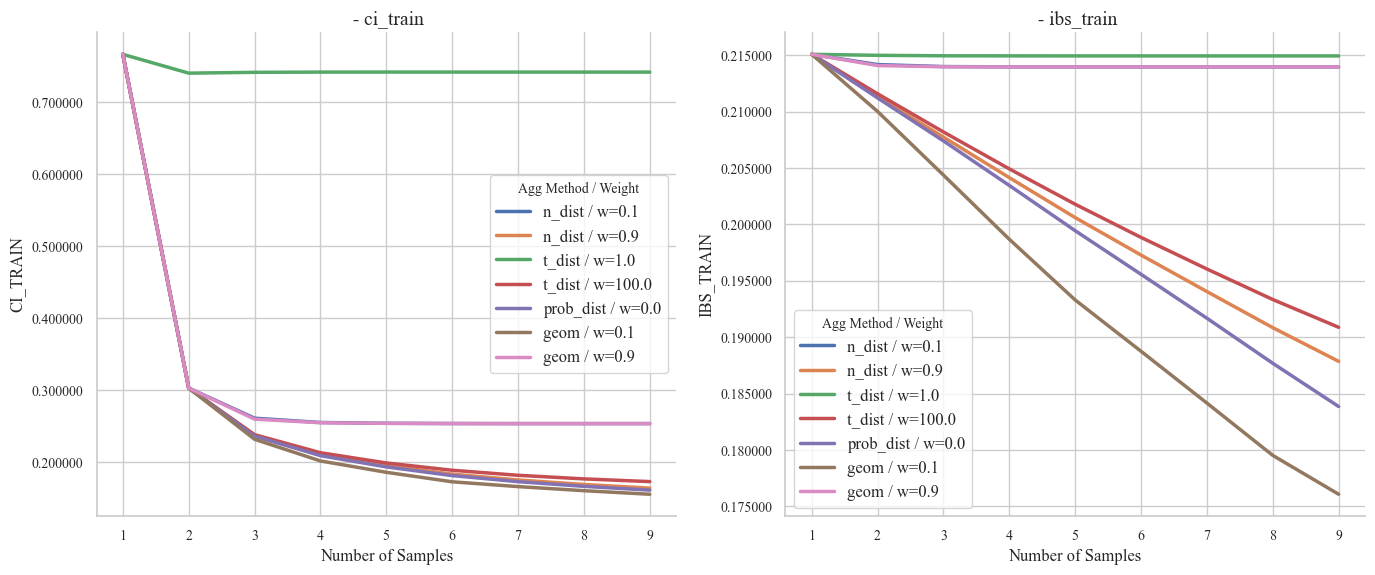

In [ ]:
aggregators_dict = {
    "n_dist": {
        "0.1": None,
        "0.9": None
    },
    "t_dist": {
        "1": None,
        "100":None 
    },
    "prob_dist": {
        "0": None,
    },
    "geom": {
        "0.1": None,
        "0.9": None
    }
}
# METHODS = ['LogReg', 'NN']
METHODS = ['Cox']
df_model = df[df['model_id'] == 105]
df_model=df
for method in METHODS:
    draw_new_plot(df_model)

# Агрегация Кокса

In [ ]:
import pandas as pd
from disk_analyzer.models.Dataset import DiskDataset
from torch.utils.data import DataLoader

train_samples = 15
TRAIN_BATCHSIZE = 1000
TO_CENS_SHIFT = range(1, 500, 50)
TO_TERM_SHIFT = range(1, 500, 50)
CENS_PROB = 0

dl_train = DataLoader(
            dataset=DiskDataset('train', [f'Preprocessed/{train_samples}_train_preprocessed.csv'],
                                to_cens_time_list=TO_CENS_SHIFT, to_term_time_list=TO_TERM_SHIFT, cens_prob=CENS_PROB),
            batch_size=TRAIN_BATCHSIZE)

In [ ]:
for what1, what2, X, y, time_to_event in dl_train:
    break

# Надо кое-что проверить

In [ ]:
import pickle
import os  # noqa
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # noqa
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"  # noqa
import numpy as np
from torch.utils.data import DataLoader
from disk_analyzer.models.Dataset import DiskDataset
from disk_analyzer.stages import ModelScorer


DATASET_TRAIN_SAMPLES = 30
MODEL_TRAIN_SAMPLES = 20
TIMES = np.arange(0, 730)

def load_model(filename):
    with open(filename, 'rb') as f:
        return pickle.load(f)

In [ ]:
model = load_model(f"Artifacts/Exp_47/models/6_SP_model.pkl")

test_samples = 10

dl_test = DataLoader(
            dataset=DiskDataset(
                'score', [f'Preprocessed/{DATASET_TRAIN_SAMPLES}_{test_samples}_test_preprocessed.csv']),
            batch_size=512)


X_pred, X_gt = model.predict(dataloader=dl_test, times=TIMES)
X_pred = X_pred.sort_values(by=['serial_number', 'time'])
X_gt = X_gt.sort_values(by=['serial_number', 'time'])

100%|██████████| 85/85 [00:30<00:00,  2.81it/s]


In [ ]:
scorer = ModelScorer()
ci_train, ibs_train, ibs_bal_train = scorer.get_ci_ibs_ibs_bal(
                            model, df_pred=X_pred, df_gt=X_gt, times=TIMES)

In [ ]:
ci_train, ibs_train, ibs_bal_train

(0.8920958480024258, 0.11203585989357887, 0.16253327868262077)

In [ ]:
def sample_first_observations(df, sample_grid):
    dict_of_all_samples = {}
    df = df.sort_values(by=['serial_number', 'time'])
    for first_n in sample_grid:
        df_train_sampled = df.groupby('serial_number').head(max(sample_grid)).groupby('serial_number').tail(first_n)
        df_train_sampled = df_train_sampled.drop_duplicates().sort_values(
            by=['serial_number', 'time'])
        dict_of_all_samples[first_n] = df_train_sampled
    return dict_of_all_samples


In [ ]:
sample_grid = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
pred_dict = sample_first_observations(X_pred, sample_grid)
gt_dict = sample_first_observations(X_gt, sample_grid) 


In [ ]:
for df1, df2 in zip(pred_dict, gt_dict):
    pred_dict
    cur_X_gt = X_gt.loc[cur_X_pred.index, :]
    cur_X_gt = cur_X_gt[cur_X_gt['time'] == cur_X_gt.groupby('serial_number')['time'].transform('max')]

In [ ]:
ci_train, ibs_train, ibs_bal_train = scorer.get_ci_ibs_ibs_bal(
                            model, df_pred=pred_dict[1], df_gt=gt_dict[1], times=TIMES)
ci_train, ibs_train, ibs_bal_train

/home/goverdovskiy/Backblaze_ML_Ops/venv/lib/python3.8/site-packages/survivors/metrics.py:268: RuntimeWarning: divide by zero encountered in divide
  brier_scores = np.where(N > 0, 1 / N, 0) * np.sum(brier_scores, axis=1)


(0.911616266597933, 0.16367700151668185, 0.10774864154897751)

In [ ]:
pred_dict[9]

,serial_number,time,0,1,2,3,4,5,6,7,...,720,721,722,723,724,725,726,727,728,729
7364,13H87YWAS,15,0.999999,0.999987,0.999941,0.999819,0.999814,0.999812,0.999802,0.999802,...,9.102146e-01,9.101931e-01,9.101817e-01,9.101785e-01,9.101394e-01,9.101348e-01,9.101346e-01,9.100919e-01,9.100175e-01,9.099269e-01
34814,13H87YWAS,79,0.999999,0.999986,0.999947,0.999839,0.999836,0.999834,0.999821,0.999821,...,9.180874e-01,9.180676e-01,9.180597e-01,9.180564e-01,9.180188e-01,9.180152e-01,9.180149e-01,9.179696e-01,9.179271e-01,9.178191e-01
22316,13H87YWAS,138,0.999999,0.999988,0.999953,0.999846,0.999843,0.999841,0.999832,0.999831,...,9.226125e-01,9.225938e-01,9.225855e-01,9.225827e-01,9.225505e-01,9.225470e-01,9.225469e-01,9.225094e-01,9.224573e-01,9.223732e-01
1717,13H87YWAS,144,0.999999,0.999987,0.999953,0.999847,0.999844,0.999842,0.999832,0.999831,...,9.231786e-01,9.231597e-01,9.231521e-01,9.231491e-01,9.231163e-01,9.231130e-01,9.231129e-01,9.230734e-01,9.230291e-01,9.229391e-01
31307,13H87YWAS,157,0.999999,0.999988,0.999955,0.999847,0.999844,0.999842,0.999834,0.999834,...,9.234694e-01,9.234515e-01,9.234429e-01,9.234404e-01,9.234096e-01,9.234061e-01,9.234060e-01,9.233714e-01,9.233124e-01,9.232377e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30446,ZCH07813,666,0.998655,0.992499,0.446043,0.442487,0.440993,0.440460,0.440196,0.440164,...,1.906065e-10,1.900711e-10,1.803818e-10,1.790842e-10,1.786009e-10,1.762389e-10,1.762180e-10,1.753871e-10,1.689695e-10,1.671256e-10
33647,ZCH07813,667,0.998646,0.992438,0.434094,0.430596,0.429032,0.428521,0.428249,0.428218,...,1.341504e-10,1.337751e-10,1.263059e-10,1.253727e-10,1.250326e-10,1.233824e-10,1.233666e-10,1.227664e-10,1.178210e-10,1.165163e-10
8276,ZCH07813,668,0.998589,0.992252,0.421088,0.417670,0.416117,0.415585,0.415318,0.415286,...,6.545080e-11,6.525660e-11,6.161131e-11,6.111739e-11,6.095115e-11,6.007937e-11,6.007146e-11,5.976449e-11,5.741995e-11,5.676311e-11
41491,ZCH07813,669,0.998756,0.992093,0.432230,0.428323,0.426315,0.425845,0.425469,0.425440,...,3.065325e-11,3.057378e-11,2.829064e-11,2.812144e-11,2.802832e-11,2.769021e-11,2.768593e-11,2.755954e-11,2.586264e-11,2.556582e-11


# Кдешки

In [ ]:
import pandas as pd
import seaborn as sns
df = pd.read_csv("Preprocessed/30_train_preprocessed.csv")

In [ ]:
df = df[['time', 'serial_number', 'failure', 'max_lifetime']]

In [ ]:
df

,time,serial_number,failure,max_lifetime
0,467,0F112CC45,0,473
1,468,0F112CC45,0,473
2,469,0F112CC45,0,473
3,470,0F112CC45,0,473
4,471,0F112CC45,0,473
...,...,...,...,...
528555,671,ZCH086CR,1,675
528556,672,ZCH086CR,1,675
528557,673,ZCH086CR,1,675
528558,674,ZCH086CR,1,675


In [ ]:
df = df[df.groupby('serial_number')['serial_number'].transform('size') > 9]

In [ ]:
N = 9
df_first = df.sort_values(by=['serial_number', 'time']).groupby('serial_number').head(N).groupby('serial_number').tail(1)

In [ ]:
df['duration'] = df_first['max_lifetime'] - df_first['time']

/tmp/ipykernel_4050047/369518185.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['duration'] = df_first['max_lifetime'] - df_first['time']


<Axes: xlabel='duration', ylabel='Density'>

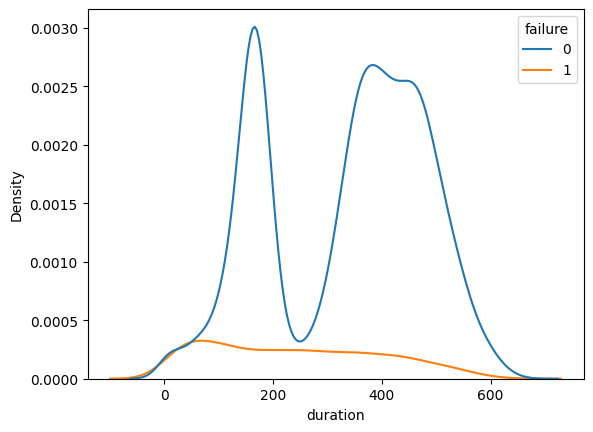

In [ ]:
sns.kdeplot(df, x='duration', hue='failure')

# Новый тест

In [ ]:
import pandas as pd

df = pd.read_csv("Preprocessed/30_25_test_preprocessed.csv")
df = df[df.groupby('serial_number')['serial_number'].transform('size') > 10]
df.to_csv('test_30_more_10.csv', index = False)

KeyboardInterrupt: 

# Сравнение двух запусков

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df_furier = pd.read_csv("Artifacts/Exp_46/grid_search.csv")
df_no_furier = pd.read_csv("Artifacts/Exp_50/grid_search.csv")
df_no_softplus = pd.read_csv("Artifacts/Exp_52/grid_search.csv")


In [ ]:

def draw_all_metrics_agg(df_full, metric, ticks, full_metrics_name=None, method=None, h_dim=None, 
                         df_second=None, first_label=None, second_label=None):
    # === Константы оформления ===
    FIGSIZE = (14, 7)
    SUPTITLE_FONTSIZE = 22
    TITLE_FONTSIZE = 13
    LABEL_FONTSIZE = 20
    TICK_FONTSIZE = 20
    LEGEND_TITLE_FONTSIZE = 20
    LEGEND_FONTSIZE = 10
    
    # Установка дефолтных labels
    if first_label is None:
        first_label = 'Основные данные'
    if second_label is None:
        second_label = 'Сравнительные данные'
    
    # Стили для разных датафреймов
    STYLES = {
        'first': {'linestyle': '-', 'marker': 'o', 'color': None},
        'second': {'linestyle': '--', 'marker': 's', 'color': None}
    }

    # Функция для фильтрации датафрейма
    def filter_df(df, method, h_dim):
        if method is not None:
            df = df[df['method'] == method]
        if h_dim is not None:
            df = df[df['hidden_dim'] == h_dim]
        return df

    # Обработка датафреймов
    df1 = filter_df(df_full.copy(), method, h_dim)
    dfs = [df1]
    df_names = ['first']
    df_labels = [first_label]
    
    if df_second is not None:
        df2 = filter_df(df_second.copy(), method, h_dim)
        dfs.append(df2)
        df_names.append('second')
        df_labels.append(second_label)

    test_grid = sorted(df1['test_samples'].dropna().unique())

    fig, ax = plt.subplots(1, 3, sharey=True, tight_layout=True, figsize=FIGSIZE)
    
    # Заголовок
    title = f'Метрика {full_metrics_name if full_metrics_name else metric}'
    if method:
        title += f', модель {method}'
    if h_dim:
        title += f', {h_dim} hidden_dim'
    if df_second is not None:
        title += ' (сравнение)'
    
    fig.suptitle(title, fontsize=SUPTITLE_FONTSIZE)
    
    # Функция для построения графиков
    def plot_subplot(ax_idx, y_column, title_text, show_legend=False):
        for i, (df, df_name, df_label) in enumerate(zip(dfs, df_names, df_labels)):
            style = STYLES[df_name]
            
            if y_column == f'{metric}_test':
                # Особый случай для test_samples с разными линиями
                for test_samples in test_grid:
                    df_filtered = df[df['test_samples'] == test_samples]
                    if not df_filtered.empty:
                        if df_second is not None:
                            label = f'{test_samples} ({df_label})'
                        else:
                            label = f'{test_samples}'
                        sns.lineplot(
                            data=df_filtered,
                            x='train_samples',
                            y=y_column,
                            estimator='mean',
                            errorbar=None,
                            linestyle=style['linestyle'],
                            marker=style['marker'],
                            color=style['color'],
                            label=label,
                            ax=ax[ax_idx]
                        )
            else:
                # Обычный случай
                label = df_label if df_second is not None else None
                
                sns.lineplot(
                    data=df,
                    x='train_samples',
                    y=y_column,
                    estimator='mean',
                    errorbar=None,
                    linestyle=style['linestyle'],
                    marker=style['marker'],
                    color=style['color'],
                    label=label,
                    ax=ax[ax_idx]
                )
        
        ax[ax_idx].set_yticks(ticks)
        ax[ax_idx].set_xlabel('n_train', fontsize=LABEL_FONTSIZE)
        if ax_idx == 0:
            ax[ax_idx].set_ylabel(metric.upper(), fontsize=LABEL_FONTSIZE)
        ax[ax_idx].set_title(title_text, fontsize=TITLE_FONTSIZE)
        ax[ax_idx].tick_params(axis='both', labelsize=TICK_FONTSIZE)
        
        if show_legend and df_second is not None:
            ax[ax_idx].legend(fontsize=LEGEND_FONTSIZE)
    
    # Построение всех трех графиков
    plot_subplot(0, f'{metric}_train_same_size', 'С длиной цепочки такого же размера', show_legend=True)
    plot_subplot(1, f'{metric}_train_max_size', 'С длиной цепочки максимального размера', show_legend=True)
    plot_subplot(2, f'{metric}_test', 'Длина цепочки в тестовой выборке', show_legend=False)
    
    # Легенда для третьего графика
    if ax[2].get_legend() is not None:
        legend = ax[2].get_legend()
        legend.set_title('Длина цепочки', prop={'size': LEGEND_TITLE_FONTSIZE})
        for text in legend.get_texts():
            text.set_fontsize(LEGEND_FONTSIZE)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:

def draw_all_metrics_agg(df_full, metric, ticks, full_metrics_name=None, method=None, h_dim=None, 
                         df_second=None, first_label=None, second_label=None):
    # === Константы оформления ===
    FIGSIZE = (14, 8)
    SUPTITLE_FONTSIZE = 22
    TITLE_FONTSIZE = 16
    LABEL_FONTSIZE = 20
    TICK_FONTSIZE = 20
    LEGEND_TITLE_FONTSIZE = 20
    LEGEND_FONTSIZE = 20
    
    # Установка дефолтных labels
    if first_label is None:
        first_label = 'Основные данные'
    if second_label is None:
        second_label = 'Сравнительные данные'
    
    # Стили для разных датафреймов
    STYLES = {
        'first': {'linestyle': '-', 'marker': 'o', 'color': None},
        'second': {'linestyle': '--', 'marker': 's', 'color': None}
    }

    # Функция для фильтрации датафрейма
    def filter_df(df, method, h_dim):
        if method is not None:
            df = df[df['method'] == method]
        if h_dim is not None:
            df = df[df['hidden_dim'] == h_dim]
        return df

    # Обработка датафреймов
    df1 = filter_df(df_full.copy(), method, h_dim)
    dfs = [df1]
    df_names = ['first']
    df_labels = [first_label]
    
    if df_second is not None:
        df2 = filter_df(df_second.copy(), method, h_dim)
        dfs.append(df2)
        df_names.append('second')
        df_labels.append(second_label)

    test_grid = sorted(df1['test_samples'].dropna().unique())

    fig, ax = plt.subplots(1, 2, sharey=True, tight_layout=True, figsize=FIGSIZE)
    
    # Заголовок
    title = f'Метрика {full_metrics_name if full_metrics_name else metric}'
    if method:
        title += f', модель {method}'
    if h_dim:
        title += f', {h_dim} hidden_dim'
    if df_second is not None:
        title += ' (сравнение)'
    
    fig.suptitle(title, fontsize=SUPTITLE_FONTSIZE)
    
    # Функция для построения графиков
    def plot_subplot(ax_idx, y_column, title_text, show_legend=False):
        for i, (df, df_name, df_label) in enumerate(zip(dfs, df_names, df_labels)):
            style = STYLES[df_name]
            
            if y_column == f'{metric}_test':
                # Особый случай для test_samples с разными линиями
                for test_samples in test_grid:
                    df_filtered = df[df['test_samples'] == test_samples]
                    if not df_filtered.empty:
                        if df_second is not None:
                            label = f'{test_samples} ({df_label})'
                        else:
                            label = f'{test_samples}'
                        sns.lineplot(
                            data=df_filtered,
                            x='train_samples',
                            y=y_column,
                            estimator='mean',
                            errorbar=None,
                            linestyle=style['linestyle'],
                            marker=style['marker'],
                            color=style['color'],
                            label=label,
                            ax=ax[ax_idx]
                        )
            else:
                # Обычный случай
                label = df_label if df_second is not None else None
                
                sns.lineplot(
                    data=df,
                    x='train_samples',
                    y=y_column,
                    estimator='mean',
                    errorbar=None,
                    linestyle=style['linestyle'],
                    marker=style['marker'],
                    color=style['color'],
                    label=label,
                    ax=ax[ax_idx]
                )
        
        ax[ax_idx].set_yticks(ticks)
        ax[ax_idx].set_xlabel('n_train', fontsize=LABEL_FONTSIZE)
        if ax_idx == 0:
            ax[ax_idx].set_ylabel(metric.upper(), fontsize=LABEL_FONTSIZE)
        ax[ax_idx].set_title(title_text, fontsize=TITLE_FONTSIZE)
        ax[ax_idx].tick_params(axis='both', labelsize=TICK_FONTSIZE)
        
        if show_legend and df_second is not None:
            ax[ax_idx].legend(fontsize=LEGEND_FONTSIZE)
    
    # Построение всех трех графиков
    plot_subplot(0, f'{metric}_train_same_size', 'С длиной цепочки такого же размера', show_legend=True)
    plot_subplot(1, f'{metric}_test', 'Длина цепочки в тестовой выборке', show_legend=False)

    
    # Легенда для третьего графика
    if ax[1].get_legend() is not None:
        legend = ax[1].get_legend()
        legend.set_title('Длина цепочки', prop={'size': LEGEND_TITLE_FONTSIZE})
        for text in legend.get_texts():
            text.set_fontsize(LEGEND_FONTSIZE)
    ax[0].grid(True)
    ax[1].grid(True)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

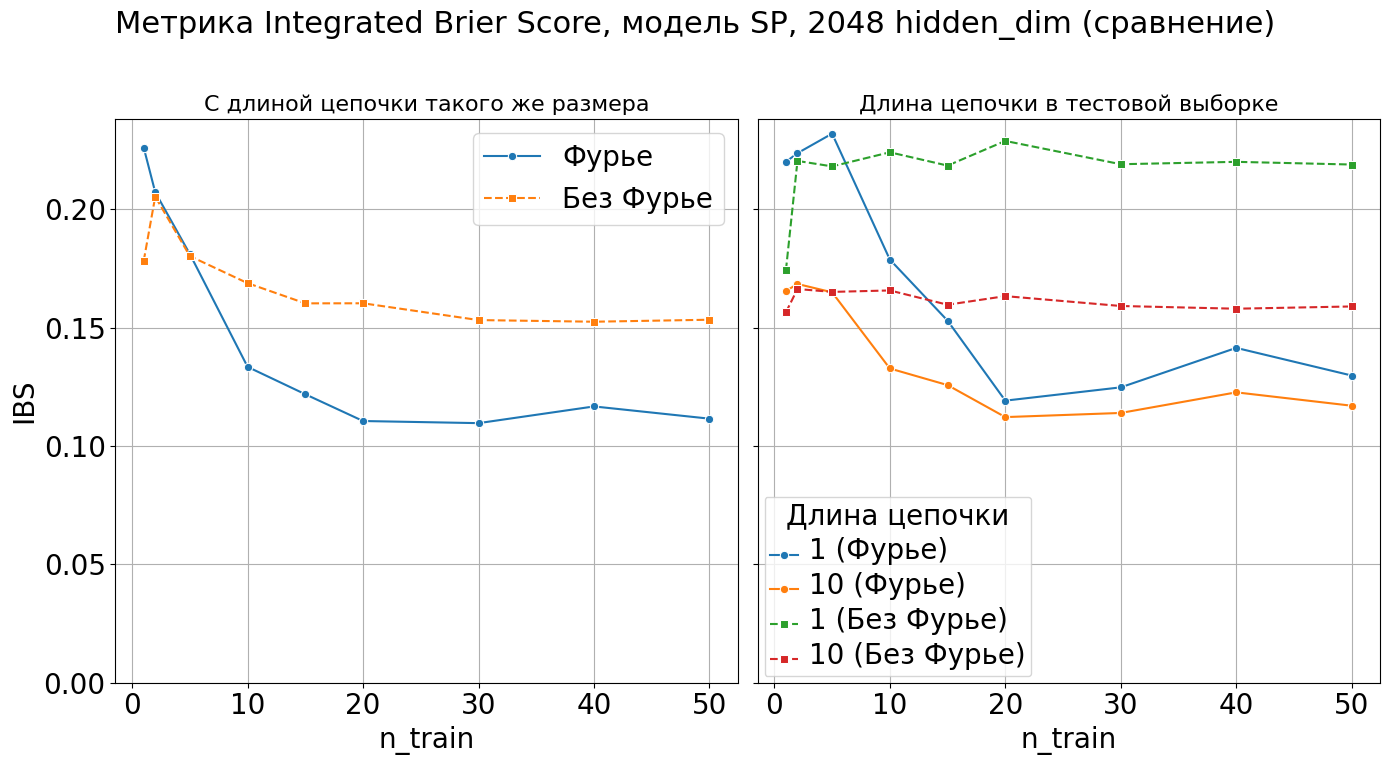

In [ ]:
draw_all_metrics_agg(df_furier, 'ibs', np.arange(0, 0.25, 0.05), full_metrics_name='Integrated Brier Score', method = 'SP', h_dim = 2048, df_second=df_no_furier, first_label='Фурье', second_label='Без Фурье')


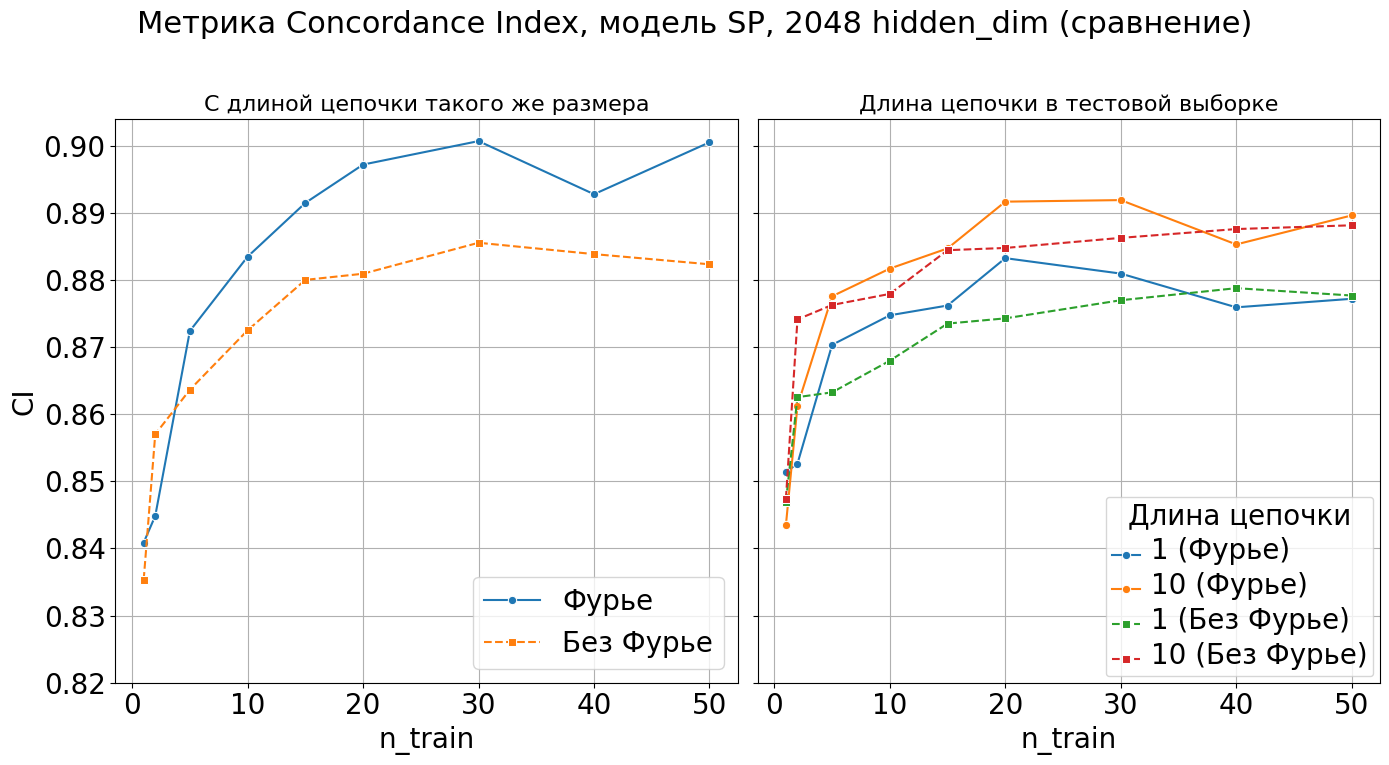

In [ ]:
draw_all_metrics_agg(df_furier, 'ci', np.arange(0.82, 0.9, 0.01), full_metrics_name='Concordance Index', method = 'SP', h_dim = 2048, df_second=df_no_furier, first_label='Фурье', second_label='Без Фурье')


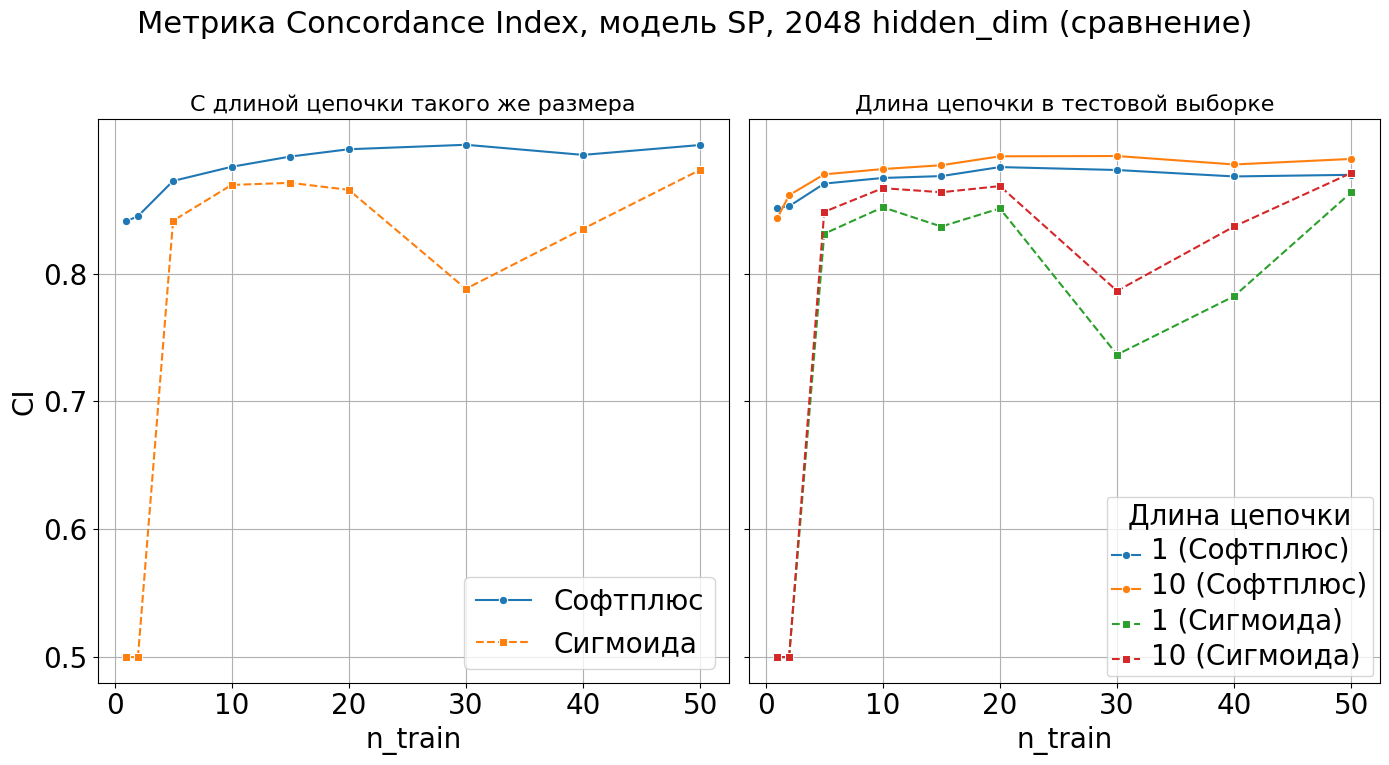

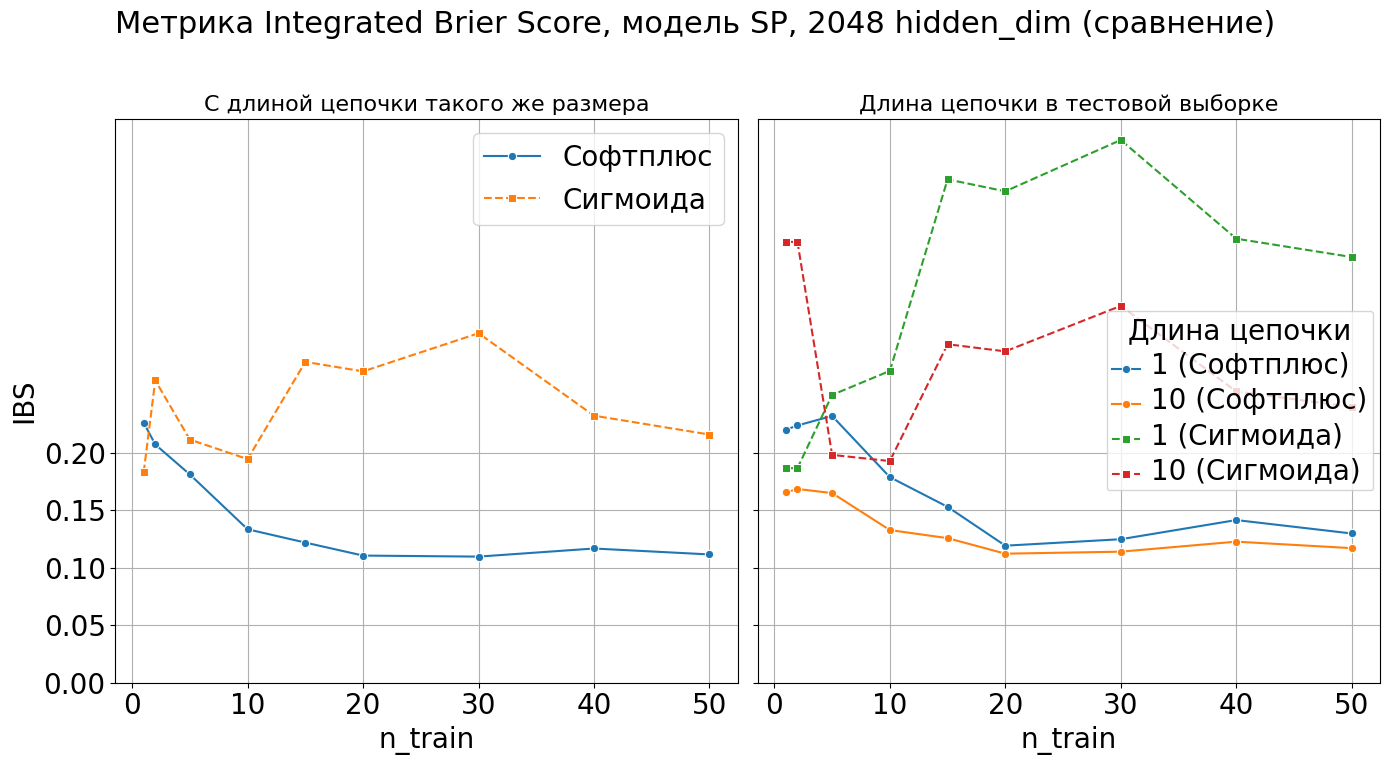

In [ ]:
draw_all_metrics_agg(df_furier, 'ci', np.arange(0.5, 0.9, 0.1), full_metrics_name='Concordance Index', method = 'SP', h_dim = 2048, df_second=df_no_softplus, first_label='Софтплюс', second_label='Сигмоида')
draw_all_metrics_agg(df_furier, 'ibs', np.arange(0, 0.25, 0.05), full_metrics_name='Integrated Brier Score', method = 'SP', h_dim = 2048, df_second=df_no_softplus, first_label='Софтплюс', second_label='Сигмоида')
